# ENVIRONMENT

In [1]:
!nvidia-smi
!lscpu
!free -h
!cat /etc/os-release
!df -h

Thu May 21 03:44:29 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# CONFIGURATIONS

In [2]:
SEED = 42
INFERENCE_BATCH_SIZE = 64
PATCH_SIZE = 64

PATHS = {
    "HKU": {
        "test_npz": "/kaggle/input/tilda-hku-patched-dataset/npz_hku_64/test_set.npz",
        "model_ckpt": "/kaggle/input/datasets/angelogoes/hku-tilda-mnet3-und1-p64/HKU_64_undersampling_ratio1_mobilenetv3_large_150d.ra4_e3600_r256_in1k/FINAL_MODEL_MedianEpoch.ckpt",
        "masks_dir": "/kaggle/input/hku-dataset"
    },
    "TILDA": {
        "test_npz": "/kaggle/input/tilda-hku-patched-dataset/npz_tilda_64/test_set.npz",
        "model_ckpt": "/kaggle/input/datasets/angelogoes/hku-tilda-mnet3-und1-p64/TILDA_64_undersampling_ratio1_mobilenetv3_large_150d.ra4_e3600_r256_in1k/FINAL_MODEL_MedianEpoch.ckpt",
        "masks_dir": "/kaggle/input/datasets/angelolmg/tilda-400/masks"
    }
}

# LIBRARIES

In [3]:
import os
import gc
import cv2
import json
import time
import copy
import random
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from tqdm import tqdm
from sklearn.metrics import precision_recall_fscore_support
import albumentations as A
from albumentations.pytorch import ToTensorV2
from datetime import datetime
from collections import Counter
import matplotlib.patches as patches

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, TensorDataset, DataLoader
import timm

import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping, Callback
from pytorch_lightning.loggers import CSVLogger

import torchmetrics
from torchmetrics.classification import (
    MulticlassF1Score, MulticlassAccuracy, MulticlassPrecision, MulticlassRecall,
    BinaryF1Score, BinaryAccuracy, BinaryPrecision, BinaryRecall
)
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

from huggingface_hub.utils import disable_progress_bars
disable_progress_bars()

def set_seed(seed: int = 42) -> None:
    # Set a fixed value for the hash seed
    os.environ["PYTHONHASHSEED"] = str(seed)
    # Set seed for PyTorch
    torch.manual_seed(seed)
    # Set seed for CUDA (if using GPUs)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  # For multi-GPU setups
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    # Set seed for Python's random module
    random.seed(seed)
    # Set seed for NumPy
    np.random.seed(seed)
    #tf.random.set_seed(seed) # set random seed for TensorFlow
    pl.seed_everything(seed, workers=True)
    print(f"[{datetime.now().strftime('%H:%M:%S')}] Seed set to {seed}")

In [4]:
!pip freeze > requirements.txt
set_seed(SEED)

Seed set to 42


[03:44:59] Seed set to 42


# UTILITIES

In [5]:
class NPZTextileDataset(Dataset):
    def __init__(self, X, transform=None):
        self.X = X
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        image = self.X[idx] # Pode vir como (H, W) ou (H, W, 1) ou (H, W, 3)
        
        # 1. Garante que o input tenha 3 canais (RGB)
        if len(image.shape) == 2:
            # Caso seja estritamente bidimensional (H, W)
            image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
        elif len(image.shape) == 3 and image.shape[-1] == 1:
            # Caso tenha formato (H, W, 1)
            image = cv2.cvtColor(image.squeeze(-1), cv2.COLOR_GRAY2RGB)
        elif len(image.shape) == 3 and image.shape[-1] == 4:
            # Segurança extra: se vier com canal Alpha (H, W, 4), remove
            image = image[..., :3]
            
        # 2. Aplica as transformações (Resize, Normalize, ToTensorV2)
        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']
            
        return image

class TextileLightningModel(pl.LightningModule):
    def __init__(self, model_name, num_classes, experiment_type="wce", class_weights=None, lr=1e-3):
        super().__init__()
        self.save_hyperparameters(ignore=['class_weights'])
        self.lr = lr
        
        self.model = timm.create_model(model_name, pretrained=False, num_classes=num_classes, in_chans=3)
        
        if experiment_type == "wce" and class_weights is not None:
            weights = torch.tensor(class_weights, dtype=torch.float32)
            self.criterion = nn.CrossEntropyLoss(weight=weights)
        else:
            self.criterion = nn.CrossEntropyLoss()
            
        self.multi_f1 = MulticlassF1Score(num_classes=num_classes, average='macro')
        self.multi_acc = MulticlassAccuracy(num_classes=num_classes, average='micro')
        self.bin_f1 = BinaryF1Score()
        self.bin_acc = BinaryAccuracy()

    def forward(self, x):
        return self.model(x)

    def configure_optimizers(self):
        optimizer = optim.AdamW(self.parameters(), lr=self.lr, weight_decay=1e-4)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=self.trainer.max_epochs)
        return [optimizer], [scheduler]

def get_eval_transform(model_name):
    temp_model = timm.create_model(model_name, pretrained=False, num_classes=0)
    data_config = timm.data.resolve_model_data_config(temp_model)
    mean, std = data_config['mean'], data_config['std']
    input_size = data_config['input_size'][-1]
    
    transform = A.Compose([
        A.Resize(input_size, input_size),
        A.Normalize(mean=mean, std=std),
        ToTensorV2()
    ])
    return transform, input_size

In [6]:
def fast_pht(probs_grid: torch.Tensor, tau_1: float, tau_2: float) -> torch.Tensor:
    """
    Algoritmo PHT vetorizado.
    probs_grid: Tensor [H, W, C] (já na GPU)
    Classe 0 = Background
    """
    H, W, C = probs_grid.shape
    
    # -------------------------
    # Passo 1 — Semente (Tau 1 / tau_h)
    # -------------------------
    pred_conf, pred_class = torch.max(probs_grid, dim=2)
    final_map = pred_class.clone()

    mask_tau1 = (pred_class != 0) & (pred_conf < tau_1)
    final_map[mask_tau1] = 0

    # -------------------------
    # Passo 2 — Expansão (Tau 2 / tau_l)
    # -------------------------
    if tau_2 > 0:
        kernel = torch.ones((1, 1, 3, 3), device=probs_grid.device)
        changed = True

        while changed:
            prev_map = final_map.clone()

            for cls in range(1, C):
                class_mask = (final_map == cls).float().unsqueeze(0).unsqueeze(0)
                dilated = F.conv2d(class_mask, kernel, padding=1) > 0
                
                grow_mask = (final_map == 0) & dilated.squeeze() & (probs_grid[..., cls] > tau_2)
                final_map[grow_mask] = cls

            changed = not torch.equal(prev_map, final_map)

    return final_map

def prepare_spatial_cache(cache_df: pd.DataFrame, num_classes: int, device='cuda') -> list:
    """
    Converte o DataFrame tabular em uma lista de grades espaciais na GPU.
    """
    if not torch.cuda.is_available() and device == 'cuda':
        device = 'cpu'
        
    # Adaptação para bater com as colunas da Fase 1 (col, row)
    unique_x = np.sort(np.unique(cache_df['col'].values))
    unique_y = np.sort(np.unique(cache_df['row'].values))
    dx = unique_x[1] - unique_x[0] if len(unique_x) > 1 else 1 
    dy = unique_y[1] - unique_y[0] if len(unique_y) > 1 else 1
    
    prob_cols = [f'prob_class_{i}' for i in range(num_classes)]
    spatial_list = []
    
    # Agrupa por img_id (equivalente ao seu group_id)
    for img_id, group_df in cache_df.groupby('img_id'):
        xs = group_df['col'].values
        ys = group_df['row'].values
        
        min_x, min_y = xs.min(), ys.min()
        col_idx = ((xs - min_x) / dx).astype(int)
        row_idx = ((ys - min_y) / dy).astype(int)
        
        W = col_idx.max() + 1
        H = row_idx.max() + 1
        
        probs_grid = torch.zeros((H, W, num_classes), device=device, dtype=torch.float32)
        probs_vals = torch.tensor(group_df[prob_cols].values, device=device, dtype=torch.float32)
        probs_grid[row_idx, col_idx] = probs_vals
        
        spatial_list.append({
            'img_id': img_id,
            'probs_grid': probs_grid,
            'row_idx': row_idx,
            'col_idx': col_idx,
            'indices': group_df.index.values 
        })
        
    return spatial_list

def apply_pht_fast(spatial_cache: list, total_patches: int, tau_1: float, tau_2: float) -> np.ndarray:
    """
    Roda o PHT em cima do cache espacial pré-processado e remonta o array 1D.
    """
    final_predictions = np.zeros(total_patches, dtype=int)
    
    for item in tqdm(spatial_cache, desc="PHT (GPU)"):
        final_map = fast_pht(item['probs_grid'], tau_1, tau_2)
        
        preds_1d = final_map[item['row_idx'], item['col_idx']].cpu().numpy()
        final_predictions[item['indices']] = preds_1d
        
    return final_predictions

In [7]:
def test_model_dummy_forward(ckpt_path):
    """
    Testa o carregamento do Checkpoint extraindo 'num_classes' e 'model_name' 
    nativamente dos hiperparâmetros salvos e faz um forward pass com um dummy tensor.
    """
    print(f"\n{'='*60}")
    print(f"🤖 TESTE DE SANIDADE DO MODELO")
    print(f"   - Checkpoint: {ckpt_path.split('/')[-1]}")
    print(f"{'='*60}")
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    if not os.path.exists(ckpt_path):
        print(f"❌ Erro: Arquivo de checkpoint não encontrado em:\n{ckpt_path}")
        return False, None
        
    try:
        # 1. Carrega os pesos e reconstrói a arquitetura magicamente via hparams
        model = TextileLightningModel.load_from_checkpoint(
            checkpoint_path=ckpt_path,
            map_location=device
        )
        model.to(device)
        model.eval()
        
        # 2. Extrai os hiperparâmetros que o Lightning recuperou do CKPT
        num_classes = model.hparams.num_classes
        model_name = model.hparams.model_name
        
        print("✅ Modelo instanciado nativamente via .hparams!")
        print(f"   - Arquitetura extraída : {model_name}")
        print(f"   - Num Classes extraído : {num_classes}")
        
        # 3. Forward Pass com Dummy Tensor (Batch=2, Canais=3, H=64, W=64)
        dummy_input = torch.randn(2, 3, PATCH_SIZE, PATCH_SIZE).to(device)
        
        with torch.no_grad():
            logits = model(dummy_input)
            
        print("✅ Forward pass executado sem erros!")
        print(f"   - Shape de Entrada : {dummy_input.shape}")
        print(f"   - Shape de Saída   : {logits.shape}")
        
        # 4. Verificação de dimensões
        if logits.shape == (2, num_classes):
            print(f"✅ Dimensões de saída perfeitas.")
            return True, model_name
        else:
            print(f"⚠️ Aviso: Dimensões não batem! Esperado (2, {num_classes}), obtido {logits.shape}.")
            return False, None
            
    except Exception as e:
        print(f"❌ Erro crítico ao testar o modelo: {e}")
        return False, None

def build_phase1_dataframe(npz_path, dataset_name):
    print(f"\n{'='*70}")
    print(f"=== FASE 1: AUDITORIA E PREPARAÇÃO | {dataset_name.upper()} ===")
    print(f"{'='*70}")
    
    # 1. Carregamento do Holdout
    data = np.load(npz_path, allow_pickle=True)
    
    df = pd.DataFrame({
        'patch_idx': np.arange(len(data['X'])),
        'img_id': data['groups'],
        'fabric_type': data['fabrics'],
        'row': data['coords'][:, 0],
        'col': data['coords'][:, 1],
        'y_multi': data['y_multi'],
        'y_binary': data['y_binary']
    })
    
    print(f"✅ Total de patches carregados: {len(df)}")
    print(f"✅ Imagens únicas mapeadas: {df['img_id'].nunique()}")
    
    # 2. Resgate das Máscaras a Nível de Pixel
    print("\n🔍 Mapeando e associando as máscaras binárias do disco...")
    if dataset_name == "TILDA":
        mask_files = list(Path(PATHS["TILDA"]["masks_dir"]).glob('*.png'))
    else:
        mask_files = list(Path(PATHS["HKU"]["masks_dir"]).rglob('groundT_*.bmp'))
        
    mask_dict = {p.stem: p for p in mask_files}
    print(f"Arquivos de máscara encontrados no diretório: {len(mask_dict)}")
    
    df['pixel_mask'] = None
    missing_masks = 0
    failed_keys = []  # Lista para armazenar as chaves não encontradas
    
    for img_id in df['img_id'].unique():
        # Lógica de correção de nomenclatura
        if dataset_name == "HKU":
            # 🛠️ CORREÇÃO DO HKU: Fatiar o img_id após o primeiro underscore '_'
            # Ex: "star_bstar_tn_d1" -> split('_', 1) -> ['star', 'bstar_tn_d1']
            parts = img_id.split('_', 1)
            
            # Se a string realmente tiver o underscore, pega a segunda parte. 
            # Se não tiver, usa ela inteira para não quebrar.
            suffix = parts[1] if len(parts) > 1 else parts[0]
            
            target_key = f"groundT_{suffix}"
        else:
            target_key = img_id
            
        # Se a imagem não tiver máscara física (amostras 'good' normais ou falhas)
        if target_key not in mask_dict:
            missing_masks += 1
            failed_keys.append((img_id, target_key))  # Guarda o ID original e a chave buscada
            
            empty_mask = np.zeros((PATCH_SIZE, PATCH_SIZE), dtype=np.uint8)
            patch_indices = df[df['img_id'] == img_id].index
            for idx in patch_indices:
                df.at[idx, 'pixel_mask'] = empty_mask
            continue
            
        # Carrega a máscara
        full_mask = cv2.imread(str(mask_dict[target_key]), cv2.IMREAD_GRAYSCALE)
        if full_mask is None:
            empty_mask = np.zeros((PATCH_SIZE, PATCH_SIZE), dtype=np.uint8)
            df.loc[df['img_id'] == img_id, 'pixel_mask'] = [empty_mask] * len(df[df['img_id'] == img_id])
            continue
            
        _, full_mask = cv2.threshold(full_mask, 127, 1, cv2.THRESH_BINARY)
        
        patch_indices = df[df['img_id'] == img_id].index
        for idx in patch_indices:
            row_idx = df.at[idx, 'row']
            col_idx = df.at[idx, 'col']
            
            y_start = row_idx * PATCH_SIZE
            x_start = col_idx * PATCH_SIZE
            
            patch_mask = full_mask[y_start:y_start+PATCH_SIZE, x_start:x_start+PATCH_SIZE]
            
            if patch_mask.shape != (PATCH_SIZE, PATCH_SIZE):
                pad_y = PATCH_SIZE - patch_mask.shape[0]
                pad_x = PATCH_SIZE - patch_mask.shape[1]
                patch_mask = np.pad(patch_mask, ((0, pad_y), (0, pad_x)), mode='constant')
                
            df.at[idx, 'pixel_mask'] = patch_mask
            
    # --- EXIBIÇÃO DE MÁSCARAS NÃO ENCONTRADAS ---
    if missing_masks > 0:
        print(f"\n⚠️ Atenção: {missing_masks} imagens não possuíam arquivos de máscara (Matrizes zeradas geradas).")
        print("📋 Lista de chaves que falharam no mapeamento (ID Original -> Chave Buscada):")
        for orig, searched in failed_keys[:30]:  # Limitado a 30 para não quebrar o layout
            print(f"   - {orig}  --> Tentou buscar por: '{searched}'")
        if len(failed_keys) > 30:
            print(f"   ... e mais {len(failed_keys) - 30} chaves.")
    else:
        print("\n✅ Sucesso: 100% das imagens associadas com suas respectivas máscaras reais!")
        
    return df, data['X']


In [8]:
def run_phase2_fast(df, X, ckpt_path, dataset_name, tau_h, tau_l, batch_size=INFERENCE_BATCH_SIZE):
    print(f"\n{'='*70}")
    print(f"=== FASE 2: INFERÊNCIA & PHT GPU | {dataset_name.upper()} ===")
    print(f"{'='*70}")
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # 1. CARREGAMENTO
    print(f"🔄 Carregando pesos e hparams...")
    model = TextileLightningModel.load_from_checkpoint(ckpt_path, map_location=device)
    model.to(device)
    model.eval()
    
    num_classes = model.hparams.num_classes
    model_name = model.hparams.model_name
    print(f"✅ Arquitetura extraída: {model_name} | Classes: {num_classes}")
    
    # 2. INFERÊNCIA BRUTA
    transform, _ = get_eval_transform(model_name)
    dataset = NPZTextileDataset(X, transform=transform)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=4)
    
    print("🧠 Extraindo probabilidades do Holdout...")
    all_probs = []
    with torch.inference_mode():
        for batch in tqdm(loader, desc="Inferência"):
            batch = batch.to(device)
            logits = model(batch)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            all_probs.append(probs)
            
    all_probs = np.vstack(all_probs)
    
    # Cria as colunas exigidas pelo prepare_spatial_cache
    for i in range(num_classes):
        df[f'prob_class_{i}'] = all_probs[:, i]
        
    # Anotações brutas para comparação posterior
    df['pred_raw_multi'] = np.argmax(all_probs, axis=1)
    df['pred_raw_binary'] = (df['pred_raw_multi'] > 0).astype(int)
    
    # 3. CONSTRUÇÃO DO CACHE E EXECUÇÃO DO PHT
    print(f"🧩 Construindo Cache Espacial na {device}...")
    spatial_cache = prepare_spatial_cache(df, num_classes, device=device)
    
    print(f"🚀 Rodando PHT Rápido (tau_h={tau_h}, tau_l={tau_l})...")
    pht_preds = apply_pht_fast(spatial_cache, len(df), tau_h, tau_l)
    
    # Consolida resultados no DataFrame Mestre
    df['pred_pht_multi'] = pht_preds
    df['pred_pht_binary'] = (pht_preds > 0).astype(int)
    
    print("✅ Fase 2 concluída!")
    return df

In [9]:
def calculate_comprehensive_metrics(df, pred_col_multi, pred_col_binary):
    """
    Calcula todas as métricas para um dado conjunto de predições.
    """
    y_true_multi = df['y_multi'].astype(int)
    y_true_bin = df['y_binary'].astype(int)
    
    y_pred_multi = df[pred_col_multi].astype(int)
    y_pred_bin = df[pred_col_binary].astype(int)
    
    metrics = {}
    
    # 1. CLASSIFICAÇÃO BINÁRIA (Defeito vs Bom)
    metrics['Bin_Acc'] = accuracy_score(y_true_bin, y_pred_bin)
    metrics['Bin_Precision'] = precision_score(y_true_bin, y_pred_bin, zero_division=0)
    metrics['Bin_Recall'] = recall_score(y_true_bin, y_pred_bin, zero_division=0)
    metrics['Bin_F1'] = f1_score(y_true_bin, y_pred_bin, zero_division=0)
    
    # 2. CLASSIFICAÇÃO MULTICLASSE
    metrics['Multi_Acc'] = accuracy_score(y_true_multi, y_pred_multi)
    metrics['Multi_F1_Macro'] = f1_score(y_true_multi, y_pred_multi, average='macro', zero_division=0)
    metrics['Multi_F1_Weighted'] = f1_score(y_true_multi, y_pred_multi, average='weighted', zero_division=0)
    
    # 3. SEGMENTAÇÃO (Patch Level IoU)
    # Interseção = ambos 1. União = pelo menos um é 1.
    patch_intersection = np.logical_and(y_true_bin == 1, y_pred_bin == 1).sum()
    patch_union = np.logical_or(y_true_bin == 1, y_pred_bin == 1).sum()
    metrics['Patch_IoU'] = patch_intersection / patch_union if patch_union > 0 else 0.0
    metrics['Patch_Dice'] = (2 * patch_intersection) / (patch_intersection + patch_union) if (patch_intersection + patch_union) > 0 else 0.0
    
    # 4. SEGMENTAÇÃO (Pixel Level IoU real)
    pixel_intersection = 0
    pixel_union = 0
    
    for _, row in df.iterrows():
        gt_mask = row['pixel_mask'] # Matriz 64x64
        pred_bin = row[pred_col_binary]
        
        # Se previu defeito, a "máscara" de predição é o patch todo aceso
        if pred_bin == 1:
            pred_mask = np.ones_like(gt_mask)
        else:
            pred_mask = np.zeros_like(gt_mask)
            
        pixel_intersection += np.logical_and(gt_mask > 0, pred_mask > 0).sum()
        pixel_union += np.logical_or(gt_mask > 0, pred_mask > 0).sum()
        
    metrics['Pixel_IoU'] = pixel_intersection / pixel_union if pixel_union > 0 else 0.0
    
    # 5. CHÃO DE FÁBRICA: Alarmes Falsos por Imagem
    # FP: Predito como defeito (1), mas na verdade é normal (0)
    df_temp = pd.DataFrame({
        'img_id': df['img_id'],
        'is_fp': (y_pred_bin == 1) & (y_true_bin == 0)
    })
    
    fp_per_image = df_temp.groupby('img_id')['is_fp'].sum()
    metrics['Mean_FP_per_Image'] = fp_per_image.mean()
    
    return metrics

def generate_analytical_plots(df, dataset_name):
    """
    Gera o painel visual de avaliação do ganho do PHT vs Baseline:
    1. Matrizes de Confusão Absolutas
    2. Matrizes de Confusão Normalizadas (Taxa de Acerto)
    3. Ganho (Delta F1) por Classe de Defeito
    4. Ganho (Delta F1 Macro) por Tipo de Tecido
    """
    print(f"\n🎨 Gerando visualizações analíticas completas para {dataset_name.upper()}...")
    
    y_true = df['y_multi'].astype(int)
    y_base = df['pred_raw_multi'].astype(int)
    y_pht = df['pred_pht_multi'].astype(int)
    
    classes = np.sort(y_true.unique())
    
    # Configuração geral do plot (Painel 3x2)
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(3, 2, figsize=(20, 20))
    fig.suptitle(f'Impacto do Algoritmo PHT - {dataset_name.upper()}', fontsize=22, fontweight='bold', y=0.95)
    
    # Adiciona o padding generoso (espaçamento vertical)
    fig.subplots_adjust(hspace=0.4, wspace=0.15, top=0.90)
    
    # ==========================================
    # 1. MATRIZES DE CONFUSÃO ABSOLUTAS (Row 1)
    # ==========================================
    cm_base = confusion_matrix(y_true, y_base, labels=classes)
    cm_pht = confusion_matrix(y_true, y_pht, labels=classes)
    
    sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0, 0], 
                xticklabels=classes, yticklabels=classes)
    axes[0, 0].set_title('Baseline (CNN Bruta) - Absoluta', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Predito')
    axes[0, 0].set_ylabel('Real')
    
    sns.heatmap(cm_pht, annot=True, fmt='d', cmap='Greens', cbar=False, ax=axes[0, 1], 
                xticklabels=classes, yticklabels=classes)
    axes[0, 1].set_title('PHT (Refinado) - Absoluta', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Predito')
    axes[0, 1].set_ylabel('Real')

    # ==========================================
    # 2. MATRIZES DE CONFUSÃO NORMALIZADAS (Row 2)
    # ==========================================
    # normalize='true' divide pelos totais da linha (Real)
    cm_base_norm = confusion_matrix(y_true, y_base, labels=classes, normalize='true')
    cm_pht_norm = confusion_matrix(y_true, y_pht, labels=classes, normalize='true')
    
    sns.heatmap(cm_base_norm, annot=True, fmt='.2f', cmap='Blues', cbar=False, ax=axes[1, 0], 
                xticklabels=classes, yticklabels=classes, vmin=0, vmax=1)
    axes[1, 0].set_title('Baseline - Normalizada (Recall)', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Predito')
    axes[1, 0].set_ylabel('Real')
    
    sns.heatmap(cm_pht_norm, annot=True, fmt='.2f', cmap='Greens', cbar=False, ax=axes[1, 1], 
                xticklabels=classes, yticklabels=classes, vmin=0, vmax=1)
    axes[1, 1].set_title('PHT - Normalizada (Recall)', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Predito')
    axes[1, 1].set_ylabel('Real')
    
    # ==========================================
    # 3. DELTA POR CLASSE DE DEFEITO (Row 3, Left)
    # ==========================================
    _, _, f1_base, _ = precision_recall_fscore_support(y_true, y_base, labels=classes, zero_division=0)
    _, _, f1_pht, _ = precision_recall_fscore_support(y_true, y_pht, labels=classes, zero_division=0)
    
    delta_class = f1_pht - f1_base
    colors_class = ['#2ca02c' if val >= 0 else '#d62728' for val in delta_class]
    
    bars_class = axes[2, 0].bar(classes.astype(str), delta_class, color=colors_class)
    axes[2, 0].set_title(r'$\Delta$ F1-Score por Classe de Defeito', fontsize=14, fontweight='bold')
    axes[2, 0].set_xlabel('Classe')
    axes[2, 0].set_ylabel('Ganho/Perda Absoluta (F1)')
    axes[2, 0].axhline(0, color='black', linewidth=1)
    
    for bar in bars_class:
        height = bar.get_height()
        axes[2, 0].annotate(f'{height:+.3f}',
                            xy=(bar.get_x() + bar.get_width() / 2, height),
                            xytext=(0, 3 if height >= 0 else -12),
                            textcoords="offset points",
                            ha='center', va='bottom' if height >= 0 else 'top',
                            fontsize=10, fontweight='bold')

    # ==========================================
    # 4. DELTA POR TIPO DE TECIDO (Row 3, Right)
    # ==========================================
    fabrics = df['fabric_type'].unique()
    delta_fabric = []
    
    for fab in fabrics:
        df_fab = df[df['fabric_type'] == fab]
        f1_b = f1_score(df_fab['y_multi'].astype(int), df_fab['pred_raw_multi'].astype(int), average='macro', zero_division=0)
        f1_p = f1_score(df_fab['y_multi'].astype(int), df_fab['pred_pht_multi'].astype(int), average='macro', zero_division=0)
        delta_fabric.append(f1_p - f1_b)
        
    colors_fab = ['#2ca02c' if val >= 0 else '#d62728' for val in delta_fabric]
    
    bars_fab = axes[2, 1].bar(fabrics.astype(str), delta_fabric, color=colors_fab)
    axes[2, 1].set_title(r'$\Delta$ F1-Score (Macro) por Tipo de Tecido', fontsize=14, fontweight='bold')
    axes[2, 1].set_xlabel('Tipo de Tecido (Background)')
    axes[2, 1].set_ylabel('Ganho/Perda Absoluta (F1 Macro)')
    axes[2, 1].axhline(0, color='black', linewidth=1)
    axes[2, 1].tick_params(axis='x', rotation=45)
    
    for bar in bars_fab:
        height = bar.get_height()
        axes[2, 1].annotate(f'{height:+.3f}',
                            xy=(bar.get_x() + bar.get_width() / 2, height),
                            xytext=(0, 3 if height >= 0 else -12),
                            textcoords="offset points",
                            ha='center', va='bottom' if height >= 0 else 'top',
                            fontsize=10, fontweight='bold')
                     
    plt.show()

def run_phase3_report(df, dataset_name):
    print(f"\n{'='*70}")
    print(f"=== FASE 3: RELATÓRIO DE MÉTRICAS | {dataset_name.upper()} ===")
    print(f"{'='*70}")
    
    # Calcula para o Baseline (Saída bruta da rede)
    base_metrics = calculate_comprehensive_metrics(df, 'pred_raw_multi', 'pred_raw_binary')
    
    # Calcula para o PHT (Pós-processado)
    pht_metrics = calculate_comprehensive_metrics(df, 'pred_pht_multi', 'pred_pht_binary')
    
    # Monta o DataFrame Comparativo
    report_df = pd.DataFrame([base_metrics, pht_metrics], index=['Baseline (Raw)', 'PHT (Refined)']).T
    
    # Adiciona coluna de ganho/perda (Delta)
    report_df['Delta (PHT - Base)'] = report_df['PHT (Refined)'] - report_df['Baseline (Raw)']
    
    # Formatação visual do print
    print(f"Resumo de Performance ({len(df)} patches processados):")
    
    # Imprimindo tabela formatada (arredondando para 4 casas decimais)
    display_df = report_df.copy()
    for col in display_df.columns:
        display_df[col] = display_df[col].apply(lambda x: f"{x:.4f}")
        
    print(display_df.to_string())
    print("-" * 70)
    
    return report_df

In [10]:
hku_model_ok, hku_model_name = test_model_dummy_forward(PATHS["HKU"]['model_ckpt'])
if hku_model_ok:
    df_hku, X_hku = build_phase1_dataframe(
        npz_path=PATHS["HKU"]['test_npz'], 
        dataset_name="HKU",
    )


tilda_model_ok, tilda_model_name = test_model_dummy_forward(PATHS["TILDA"]['model_ckpt'])
if tilda_model_ok:
    df_tilda, X_tilda = build_phase1_dataframe(
        npz_path=PATHS["TILDA"]['test_npz'], 
        dataset_name="TILDA"
    )


🤖 TESTE DE SANIDADE DO MODELO
   - Checkpoint: FINAL_MODEL_MedianEpoch.ckpt
✅ Modelo instanciado nativamente via .hparams!
   - Arquitetura extraída : mobilenetv3_large_150d.ra4_e3600_r256_in1k
   - Num Classes extraído : 7
✅ Forward pass executado sem erros!
   - Shape de Entrada : torch.Size([2, 3, 64, 64])
   - Shape de Saída   : torch.Size([2, 7])
✅ Dimensões de saída perfeitas.

=== FASE 1: AUDITORIA E PREPARAÇÃO | HKU ===
✅ Total de patches carregados: 528
✅ Imagens únicas mapeadas: 33

🔍 Mapeando e associando as máscaras binárias do disco...
Arquivos de máscara encontrados no diretório: 81

⚠️ Atenção: 17 imagens não possuíam arquivos de máscara (Matrizes zeradas geradas).
📋 Lista de chaves que falharam no mapeamento (ID Original -> Chave Buscada):
   - star_bstar_p5  --> Tentou buscar por: 'groundT_bstar_p5'
   - star_bstar_p2  --> Tentou buscar por: 'groundT_bstar_p2'
   - box_Bbox_p28  --> Tentou buscar por: 'groundT_Bbox_p28'
   - box_Bbox_p10  --> Tentou buscar por: 'groun

In [11]:
# HKU:
if 'df_hku' in locals() and 'X_hku' in locals():
    df_hku = run_phase2_fast(
        df=df_hku,
        X=X_hku,
        ckpt_path=PATHS["HKU"]["model_ckpt"],
        dataset_name="HKU",
        tau_h=0.38,
        tau_l=0.21
    )

# TILDA:
if 'df_tilda' in locals() and 'X_tilda' in locals():
    df_tilda = run_phase2_fast(
        df=df_tilda,
        X=X_tilda,
        ckpt_path=PATHS["TILDA"]["model_ckpt"],
        dataset_name="TILDA",
        tau_h=0.90,
        tau_l=0.56
    )


=== FASE 2: INFERÊNCIA & PHT GPU | HKU ===
🔄 Carregando pesos e hparams...
✅ Arquitetura extraída: mobilenetv3_large_150d.ra4_e3600_r256_in1k | Classes: 7
🧠 Extraindo probabilidades do Holdout...


Inferência: 100%|██████████| 9/9 [00:01<00:00,  5.55it/s]


🧩 Construindo Cache Espacial na cuda...
🚀 Rodando PHT Rápido (tau_h=0.38, tau_l=0.21)...


PHT (GPU): 100%|██████████| 33/33 [00:00<00:00, 45.25it/s]


✅ Fase 2 concluída!

=== FASE 2: INFERÊNCIA & PHT GPU | TILDA ===
🔄 Carregando pesos e hparams...
✅ Arquitetura extraída: mobilenetv3_large_150d.ra4_e3600_r256_in1k | Classes: 5
🧠 Extraindo probabilidades do Holdout...


Inferência: 100%|██████████| 120/120 [00:17<00:00,  6.90it/s]


🧩 Construindo Cache Espacial na cuda...
🚀 Rodando PHT Rápido (tau_h=0.9, tau_l=0.56)...


PHT (GPU): 100%|██████████| 80/80 [00:00<00:00, 206.12it/s]

✅ Fase 2 concluída!



=== FASE 3: RELATÓRIO DE MÉTRICAS | HKU ===
Resumo de Performance (528 patches processados):
                  Baseline (Raw) PHT (Refined) Delta (PHT - Base)
Bin_Acc                   0.9924        0.9867            -0.0057
Bin_Precision             0.9062        0.8286            -0.0777
Bin_Recall                0.9667        0.9667             0.0000
Bin_F1                    0.9355        0.8923            -0.0432
Multi_Acc                 0.9792        0.9735            -0.0057
Multi_F1_Macro            0.7788        0.7496            -0.0292
Multi_F1_Weighted         0.9797        0.9751            -0.0046
Patch_IoU                 0.8788        0.8056            -0.0732
Patch_Dice                0.9355        0.8923            -0.0432
Pixel_IoU                 0.1040        0.1005            -0.0034
Mean_FP_per_Image         0.0909        0.1818             0.0909
----------------------------------------------------------------------

🎨 Gerando visualizações analíticas complet

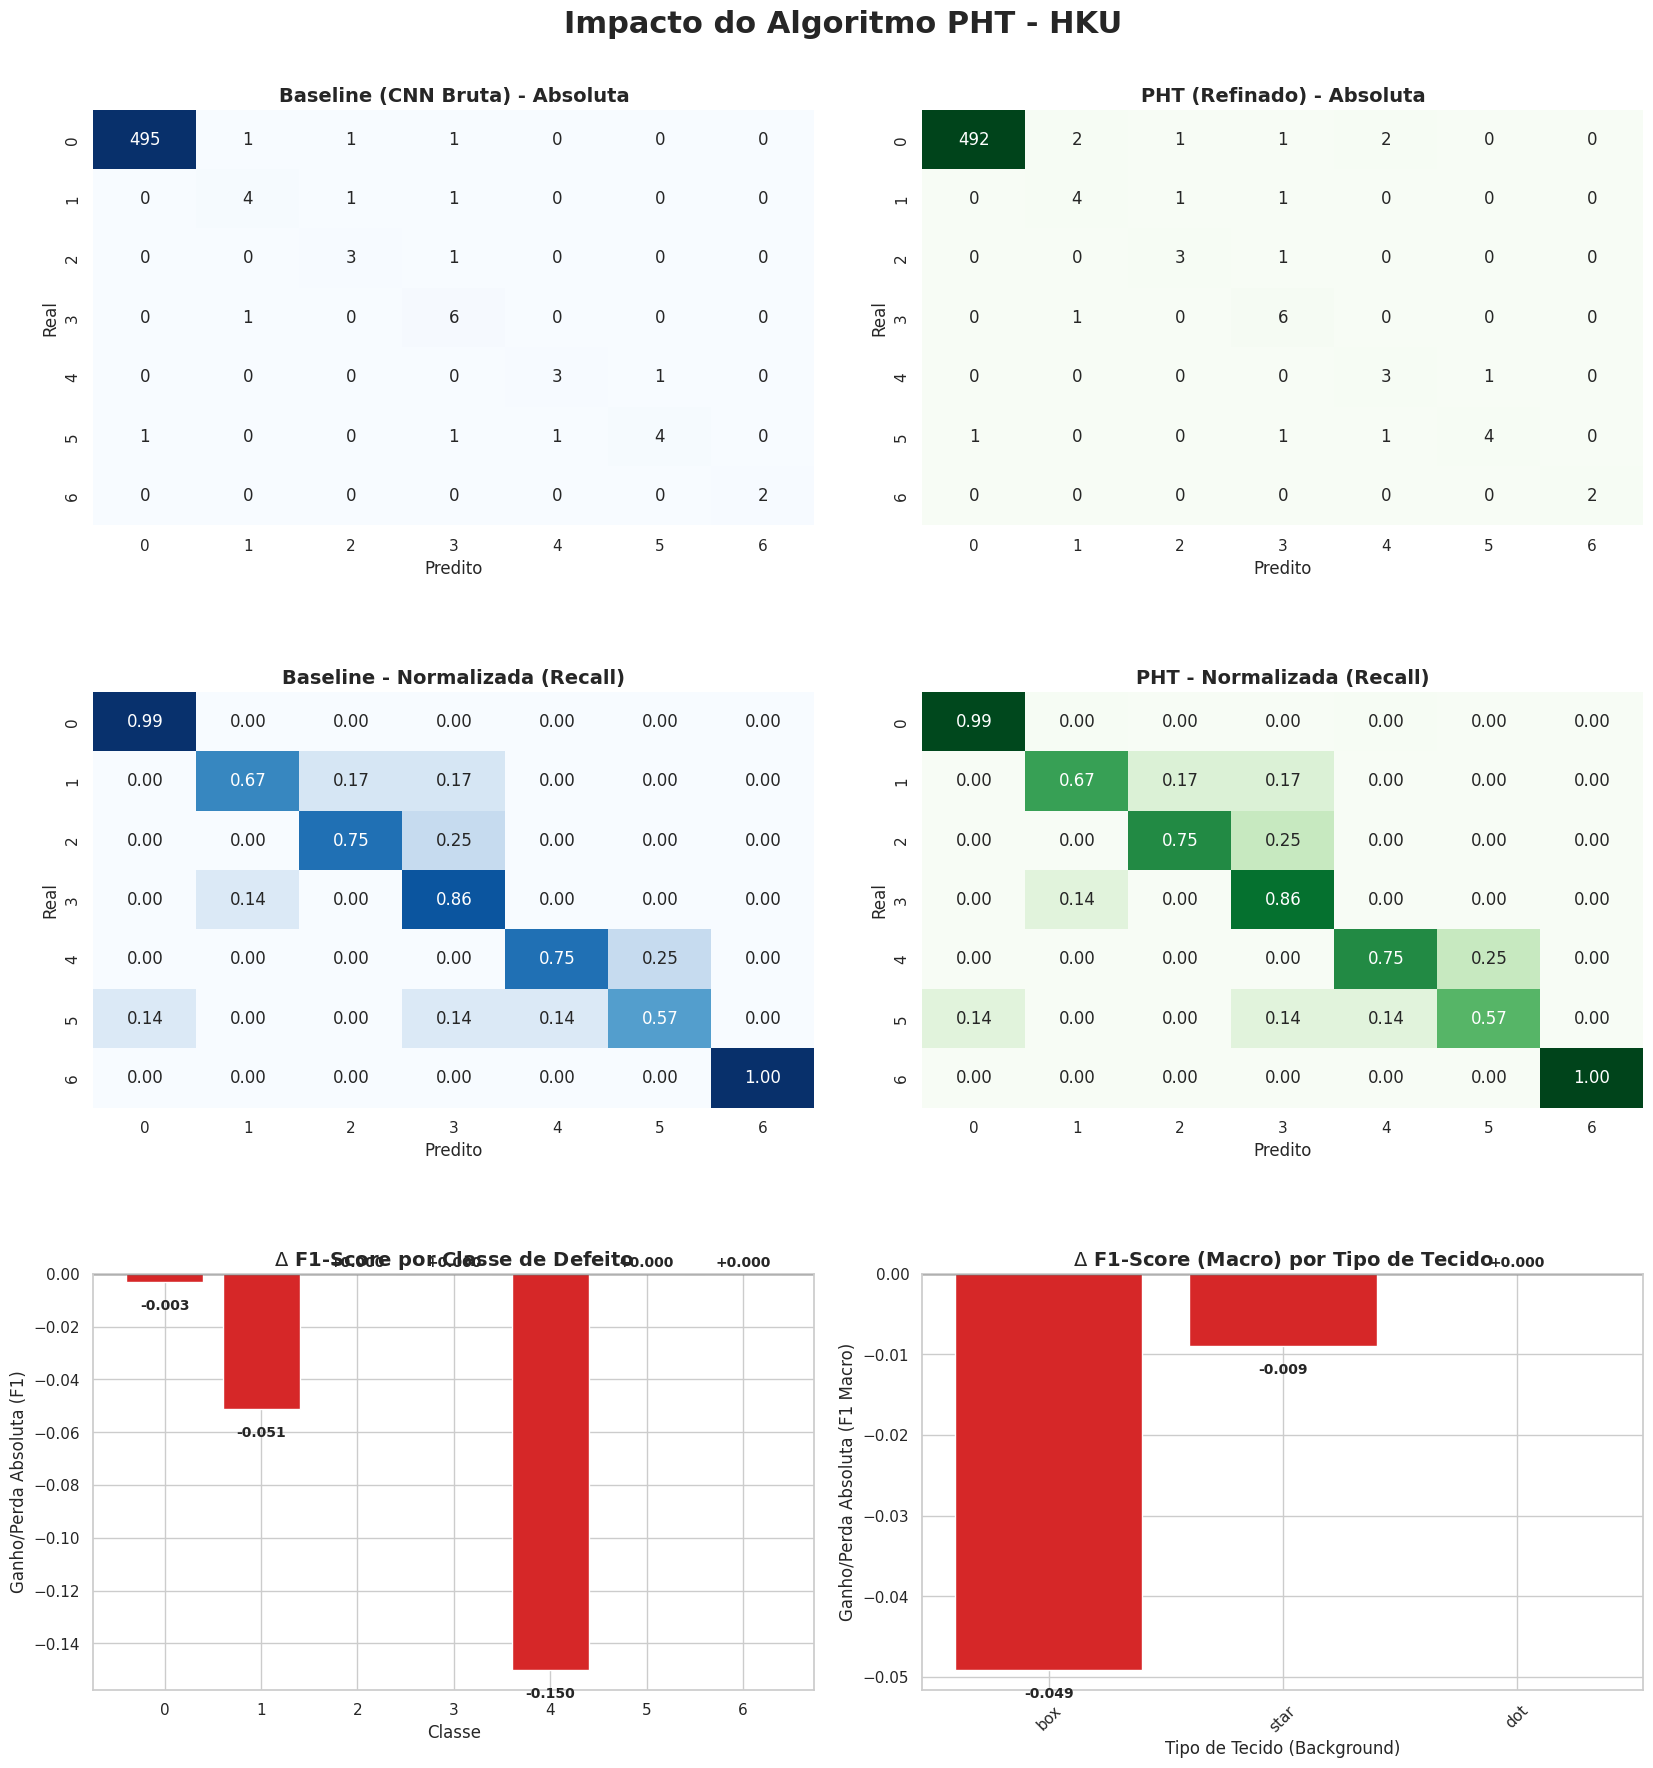


=== FASE 3: RELATÓRIO DE MÉTRICAS | TILDA ===
Resumo de Performance (7680 patches processados):
                  Baseline (Raw) PHT (Refined) Delta (PHT - Base)
Bin_Acc                   0.9688        0.9745             0.0057
Bin_Precision             0.6095        0.6660             0.0566
Bin_Recall                0.9534        0.9288            -0.0247
Bin_F1                    0.7436        0.7757             0.0322
Multi_Acc                 0.9671        0.9734             0.0064
Multi_F1_Macro            0.7713        0.8037             0.0324
Multi_F1_Weighted         0.9706        0.9756             0.0050
Patch_IoU                 0.5918        0.6336             0.0418
Patch_Dice                0.7436        0.7757             0.0322
Pixel_IoU                 0.2294        0.2471             0.0177
Mean_FP_per_Image         2.7875        2.1250            -0.6625
----------------------------------------------------------------------

🎨 Gerando visualizações analíticas comp

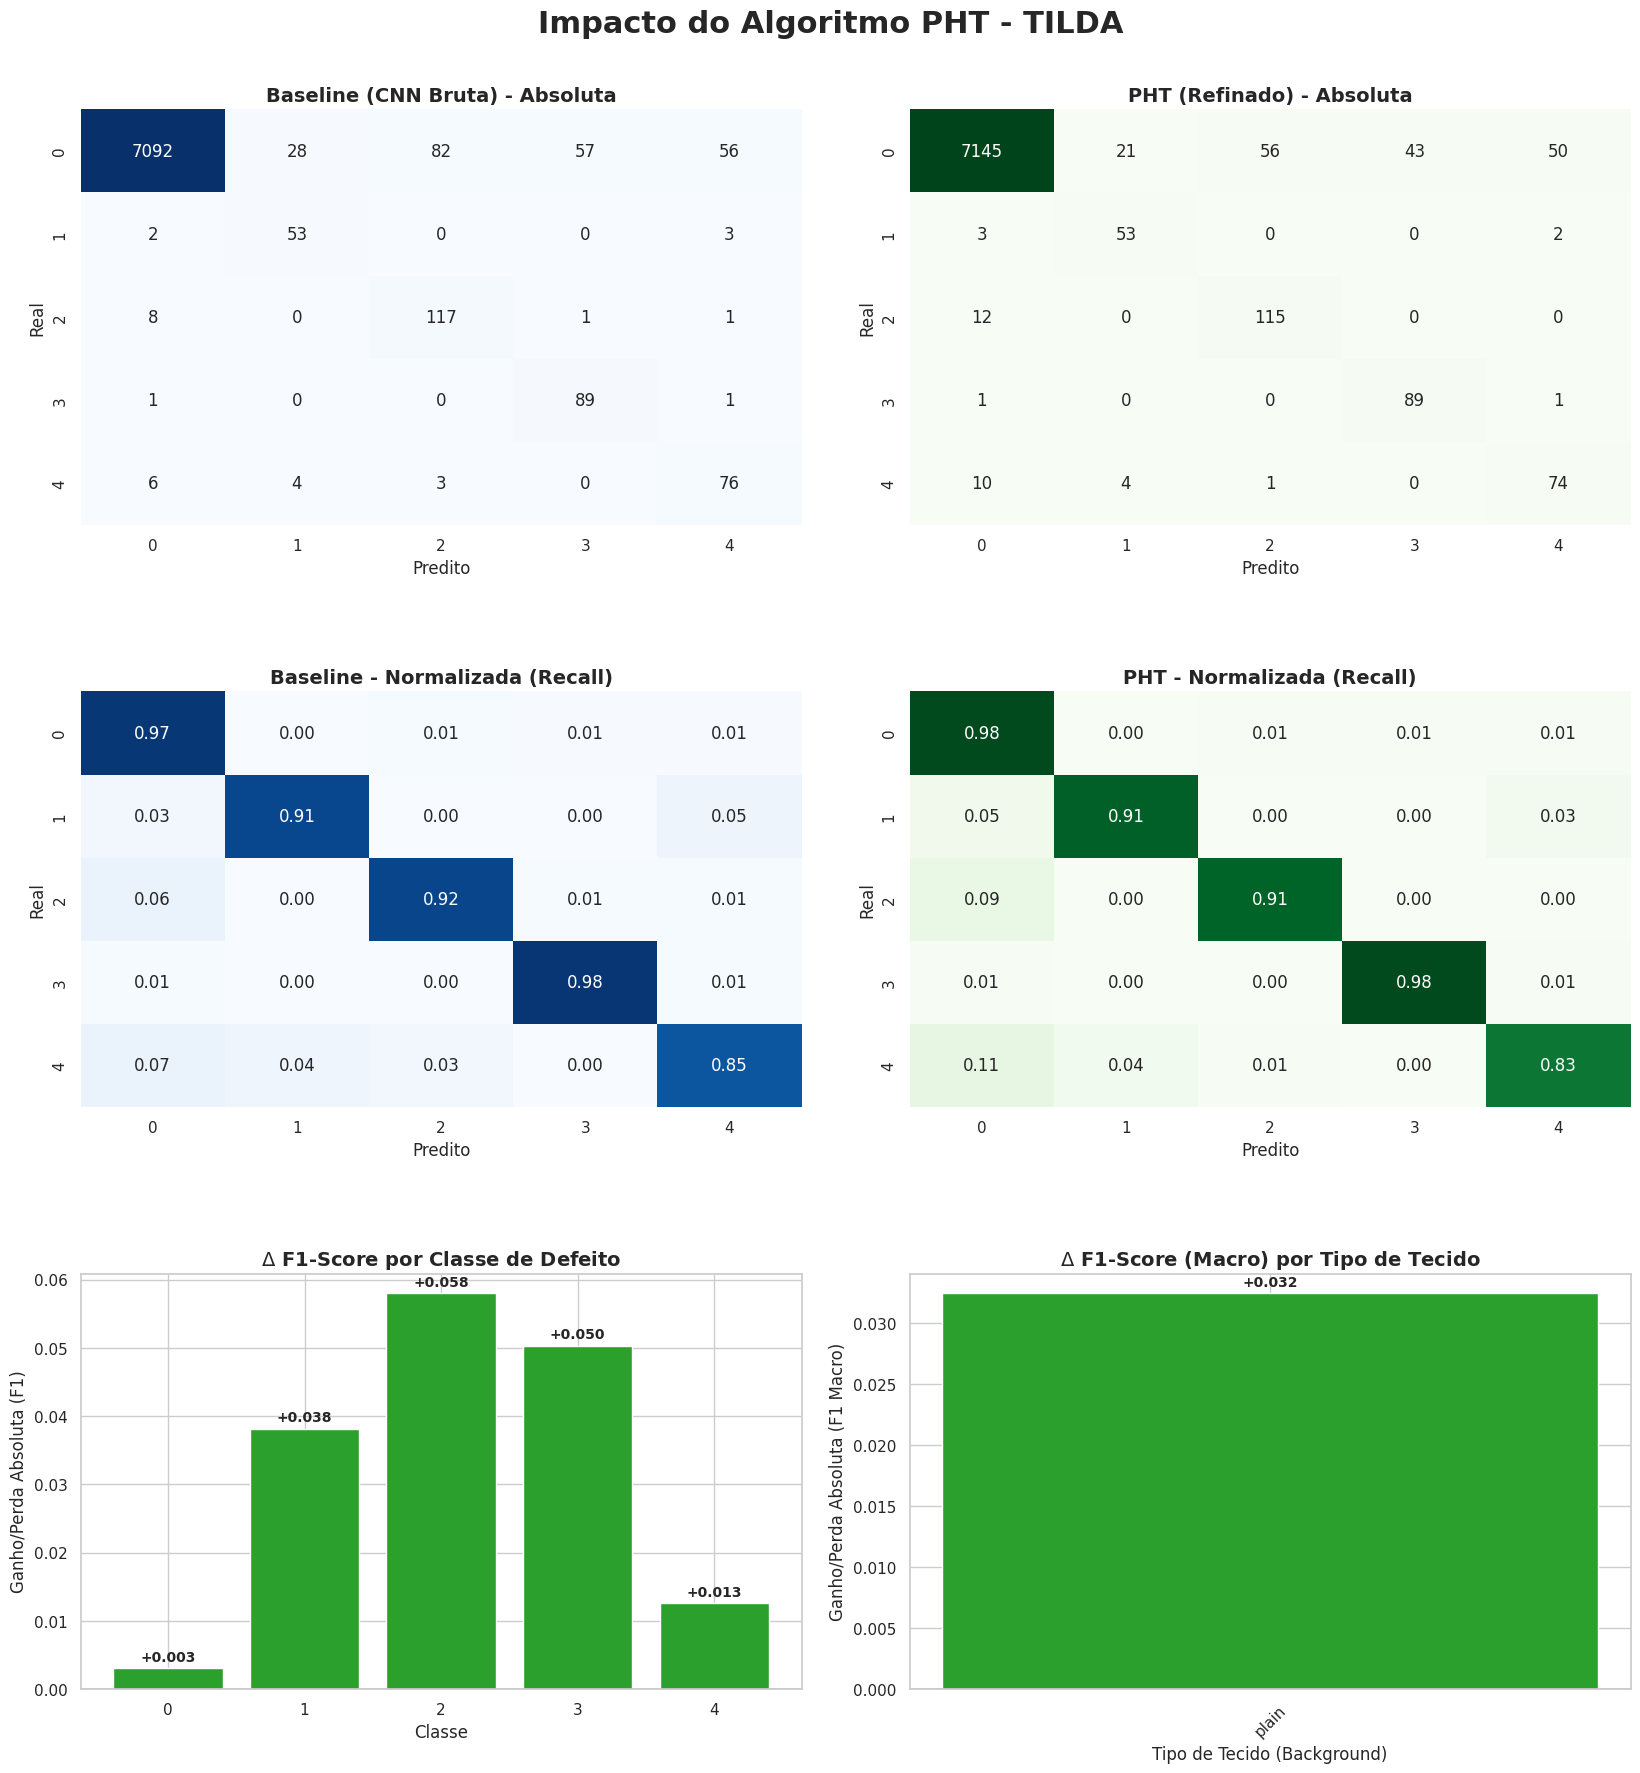

In [12]:
# Para HKU:
if 'df_hku' in locals():
    report_hku = run_phase3_report(df_hku, "HKU")
    generate_analytical_plots(df_hku, "HKU")

# Para TILDA:
if 'df_tilda' in locals():
    report_tilda = run_phase3_report(df_tilda, "TILDA")
    generate_analytical_plots(df_tilda, "TILDA")

In [13]:
def run_phase4_bootstrapping(df, dataset_name, n_iterations=1000, seed=42):
    print(f"\n{'='*70}")
    print(f"=== FASE 4: CLUSTER BOOTSTRAPPING (1.000 iter) | {dataset_name.upper()} ===")
    print(f"{'='*70}")
    
    np.random.seed(seed)
    
    # 1. PRÉ-CACHEAMENTO (Otimização Extrema)
    print("📦 Pré-cacheando arrays por imagem para aceleração máxima...")
    unique_images = df['img_id'].unique()
    img_dict = {}
    
    for img in unique_images:
        mask = df['img_id'] == img
        img_dict[img] = {
            'y_t_m': df.loc[mask, 'y_multi'].values.astype(int),
            'y_b_m': df.loc[mask, 'pred_raw_multi'].values.astype(int),
            'y_p_m': df.loc[mask, 'pred_pht_multi'].values.astype(int),
            'y_t_b': df.loc[mask, 'y_binary'].values.astype(int),
            'y_b_b': df.loc[mask, 'pred_raw_binary'].values.astype(int),
            'y_p_b': df.loc[mask, 'pred_pht_binary'].values.astype(int),
        }

    # Estruturas para armazenar os Deltas de cada iteração
    deltas = {
        'F1_Macro': np.zeros(n_iterations),
        'F1_Weighted': np.zeros(n_iterations),
        'Patch_IoU': np.zeros(n_iterations),
        'Missed_Defect_Rate': np.zeros(n_iterations)
    }
    
    # 2. LAÇO DE BOOTSTRAPPING
    print(f"🎲 Iniciando {n_iterations} sorteios com reposição (Agrupado por img_id)...")
    for i in tqdm(range(n_iterations), desc="Bootstrapping"):
        # Sorteia as imagens com reposição
        sampled_imgs = np.random.choice(unique_images, size=len(unique_images), replace=True)
        
        # Concatena os patches das imagens sorteadas
        y_t_m = np.concatenate([img_dict[img]['y_t_m'] for img in sampled_imgs])
        y_b_m = np.concatenate([img_dict[img]['y_b_m'] for img in sampled_imgs])
        y_p_m = np.concatenate([img_dict[img]['y_p_m'] for img in sampled_imgs])
        
        y_t_b = np.concatenate([img_dict[img]['y_t_b'] for img in sampled_imgs])
        y_b_b = np.concatenate([img_dict[img]['y_b_b'] for img in sampled_imgs])
        y_p_b = np.concatenate([img_dict[img]['y_p_b'] for img in sampled_imgs])
        
        # --- Cálculo dos KPIs para o Baseline ---
        b_f1_mac = f1_score(y_t_m, y_b_m, average='macro', zero_division=0)
        b_f1_wei = f1_score(y_t_m, y_b_m, average='weighted', zero_division=0)
        
        b_inter = np.logical_and(y_t_b == 1, y_b_b == 1).sum()
        b_union = np.logical_or(y_t_b == 1, y_b_b == 1).sum()
        b_iou = b_inter / b_union if b_union > 0 else 0
        
        # Missed Defect Rate = FN / (FN + TP) -> Omissão de patches defeituosos reais
        b_fn = np.logical_and(y_t_b == 1, y_b_b == 0).sum()
        actual_defects = (y_t_b == 1).sum()
        b_mdr = b_fn / actual_defects if actual_defects > 0 else 0
        
        # --- Cálculo dos KPIs para o PHT ---
        p_f1_mac = f1_score(y_t_m, y_p_m, average='macro', zero_division=0)
        p_f1_wei = f1_score(y_t_m, y_p_m, average='weighted', zero_division=0)
        
        p_inter = np.logical_and(y_t_b == 1, y_p_b == 1).sum()
        p_union = np.logical_or(y_t_b == 1, y_p_b == 1).sum()
        p_iou = p_inter / p_union if p_union > 0 else 0
        
        p_fn = np.logical_and(y_t_b == 1, y_p_b == 0).sum()
        p_mdr = p_fn / actual_defects if actual_defects > 0 else 0
        
        # --- Armazenando os Deltas (PHT - Baseline) ---
        deltas['F1_Macro'][i] = p_f1_mac - b_f1_mac
        deltas['F1_Weighted'][i] = p_f1_wei - b_f1_wei
        deltas['Patch_IoU'][i] = p_iou - b_iou
        deltas['Missed_Defect_Rate'][i] = p_mdr - b_mdr

    # 3. CONSOLIDAÇÃO ESTATÍSTICA (Intervalo de Confiança de 95%)
    print("\n📊 Resultados da Validação Estatística (Delta PHT vs Baseline):")
    results = []
    
    for kpi, d_array in deltas.items():
        mean_delta = np.mean(d_array)
        ci_lower = np.percentile(d_array, 2.5)
        ci_upper = np.percentile(d_array, 97.5)
        
        # Avalia significância estatística (Se o IC cruza o zero, não é estatisticamente significativo)
        if ci_lower > 0:
            sig = "✅ Ganho Significativo"
        elif ci_upper < 0:
            if kpi == 'Missed_Defect_Rate':
                sig = "✅ Queda Significativa (Melhora!)"
            else:
                sig = "❌ Perda Significativa"
        else:
            sig = "⚠️ Empate Técnico (Cruza o 0)"
            
        results.append({
            'KPI': kpi.replace('_', ' '),
            'Mean Delta': mean_delta,
            'CI 95% Lower': ci_lower,
            'CI 95% Upper': ci_upper,
            'Significância': sig
        })
        
    df_stats = pd.DataFrame(results)
    
    # Formatação visual
    display_df = df_stats.copy()
    for col in ['Mean Delta', 'CI 95% Lower', 'CI 95% Upper']:
        display_df[col] = display_df[col].apply(lambda x: f"{x:+.4f}")
        
    print(display_df.to_string(index=False))
    print("-" * 70)
    
    return df_stats, deltas

In [14]:
# Para HKU:
if 'df_hku' in locals():
    stats_hku, deltas_dist_hku = run_phase4_bootstrapping(df_hku, "HKU")

# Para TILDA:
if 'df_tilda' in locals():
    stats_tilda, deltas_dist_tilda = run_phase4_bootstrapping(df_tilda, "TILDA")


=== FASE 4: CLUSTER BOOTSTRAPPING (1.000 iter) | HKU ===
📦 Pré-cacheando arrays por imagem para aceleração máxima...
🎲 Iniciando 1000 sorteios com reposição (Agrupado por img_id)...


Bootstrapping: 100%|██████████| 1000/1000 [00:05<00:00, 169.70it/s]



📊 Resultados da Validação Estatística (Delta PHT vs Baseline):
               KPI Mean Delta CI 95% Lower CI 95% Upper                 Significância
          F1 Macro    -0.0251      -0.0582      +0.0000 ⚠️ Empate Técnico (Cruza o 0)
       F1 Weighted    -0.0045      -0.0122      +0.0000 ⚠️ Empate Técnico (Cruza o 0)
         Patch IoU    -0.0703      -0.1737      +0.0000 ⚠️ Empate Técnico (Cruza o 0)
Missed Defect Rate    +0.0000      +0.0000      +0.0000 ⚠️ Empate Técnico (Cruza o 0)
----------------------------------------------------------------------

=== FASE 4: CLUSTER BOOTSTRAPPING (1.000 iter) | TILDA ===
📦 Pré-cacheando arrays por imagem para aceleração máxima...
🎲 Iniciando 1000 sorteios com reposição (Agrupado por img_id)...


Bootstrapping: 100%|██████████| 1000/1000 [00:07<00:00, 139.39it/s]


📊 Resultados da Validação Estatística (Delta PHT vs Baseline):
               KPI Mean Delta CI 95% Lower CI 95% Upper         Significância
          F1 Macro    +0.0333      +0.0222      +0.0457 ✅ Ganho Significativo
       F1 Weighted    +0.0049      +0.0031      +0.0067 ✅ Ganho Significativo
         Patch IoU    +0.0417      +0.0199      +0.0612 ✅ Ganho Significativo
Missed Defect Rate    +0.0242      +0.0081      +0.0455 ✅ Ganho Significativo
----------------------------------------------------------------------


In [15]:
def run_pipeline_speed_benchmark(
    model_path,
    patch_size=64,
    image_height=256,
    image_width=4096,
    tau_1=0.5,
    tau_2=0.7,
    num_runs=20,
    warmup_runs=5,
    inference_batch_size=256,
    use_fp16=True,
    use_compile=True,
    use_multiple_gpu=False
):
    """
    Benchmark de Throughput ponta a ponta integrado nativamente 
    com o TextileLightningModel e otimizado com CUDA Events.
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "GPU"

    # 1. CARREGAMENTO AUTOMÁTICO VIA LIGHTNING
    print("\n⚡ Carregando modelo nativamente via Lightning Checkpoint...")
    try:
        # O método load_from_checkpoint resolve o model_name e num_classes sozinho pelas hparams
        model = TextileLightningModel.load_from_checkpoint(model_path, map_location=device)
    except Exception as e:
        raise RuntimeError(f"❌ Falha ao carregar o .ckpt. Certifique-se de passar um arquivo válido do Lightning. Erro: {e}")
    
    model.eval()
    
    # Extrai as informações de dentro do modelo instanciado para o log
    model_name = model.hparams.model_name
    num_classes = model.hparams.num_classes

    print(f"\n{'='*70}")
    print(f"=== FASE 5: BENCHMARK PIPELINE COMPLETO | HARDWARE: {gpu_name.upper()} ===")
    print(f"{'='*70}")
    print(f"🧠 Modelo Detectado: {model_name} ({num_classes} classes)")
    print(f"📐 Buffer de Imagem: {image_height}x{image_width} | Patch size: {patch_size}")
    print(f"🎛️ Parâmetros PHT: Tau1={tau_1} | Tau2={tau_2}")
    print(f"⚙️ Configuração: Rodadas={num_runs} (Warmup={warmup_runs})")
    print(f"🚀 Otimizações: FP16={use_fp16} | Compile={use_compile}")

    if device.type == "cuda":
        torch.backends.cudnn.benchmark = True

    # 2. APLICAÇÃO DE OTIMIZAÇÕES DE RUNTIME
    if use_fp16 and device.type == "cuda":
        model = model.half()

    if use_compile:
        print("⚡ Compilando modelo com torch.compile (reduce-overhead)...")
        model = torch.compile(model, mode="reduce-overhead")

    # 3. GERAÇÃO DO BUFFER SINTÉTICO DIRETO NO DEVICE
    image = torch.randn(1, 3, image_height, image_width, device=device)
    if use_fp16 and device.type == "cuda":
        image = image.half()

    n_patches_h = image_height // patch_size
    n_patches_w = image_width // patch_size
    total_patches = n_patches_h * n_patches_w

    print(f"Dimensões do Grid: {n_patches_h} x {n_patches_w} = {total_patches} patches totais.")

    # Estruturas para métricas de tempo
    preprocessing_times = []
    inference_times = []
    postprocessing_times = []
    total_times = []

    start_pre = torch.cuda.Event(enable_timing=True)
    end_pre = torch.cuda.Event(enable_timing=True)
    start_inf = torch.cuda.Event(enable_timing=True)
    end_inf = torch.cuda.Event(enable_timing=True)
    start_post = torch.cuda.Event(enable_timing=True)
    end_post = torch.cuda.Event(enable_timing=True)

    print(f"\n🚀 Iniciando loops de medição...")
    for run in range(num_runs):
        is_warmup = run < warmup_runs
        
        # FASE 1 — PREPROCESSAMENTO (Slicing na GPU)
        start_pre.record()
        patches = image.unfold(2, patch_size, patch_size)\
                       .unfold(3, patch_size, patch_size)\
                       .reshape(-1, 3, patch_size, patch_size)
        end_pre.record()

        # FASE 2 — INFERÊNCIA
        start_inf.record()
        with torch.inference_mode():
            if total_patches <= inference_batch_size:
                logits = model(patches)
            else:
                logits = torch.empty(
                    (total_patches, num_classes), 
                    dtype=torch.float16 if use_fp16 else torch.float32, 
                    device=device
                )
                for i in range(0, total_patches, inference_batch_size):
                    end = min(i + inference_batch_size, total_patches)
                    logits[i:end] = model(patches[i:end])
        end_inf.record()

        # FASE 3 — PÓS-PROCESSAMENTO (Filtro Histerese PHT)
        start_post.record()
        logits_grid = logits.view(n_patches_h, n_patches_w, -1)
        final_map = fast_pht(logits_grid, tau_1, tau_2)
        end_post.record()

        torch.cuda.synchronize()

        if not is_warmup:
            t_pre = start_pre.elapsed_time(end_pre)
            t_inf = start_inf.elapsed_time(end_inf)
            t_post = start_post.elapsed_time(end_post)
            
            preprocessing_times.append(t_pre)
            inference_times.append(t_inf)
            postprocessing_times.append(t_post)
            total_times.append(t_pre + t_inf + t_post)

    # 4. EXIBIÇÃO DOS RESULTADOS FINAIS
    print("\n" + "="*30 + " RESULTADOS FINAIS " + "="*30)
    
    def summarize_ms(name, values):
        mean = np.mean(values)
        std = np.std(values)
        print(f"   - {name:<22}: {mean:.2f} ms ± {std:.2f} ms")
        return mean, std

    mean_pre, std_pre = summarize_ms("Preprocessing", preprocessing_times)
    mean_inf, std_inf = summarize_ms("Inference", inference_times)
    mean_post, std_post = summarize_ms("Post-processing (PHT)", postprocessing_times)
    mean_total, std_total = summarize_ms("Total Pipeline Time", total_times)
    
    throughput = 1.0 / (mean_total / 1000.0)
    print(f"\n📊 Throughput alcançado: {throughput:.2f} imagens/segundo")
    print("="*70)

    # 5. GENERAR GRÁFICO DE BARRAS EMPILHADAS
    sns.set_theme(style="whitegrid")
    phases = ['Preprocessing', 'Inference', 'Post-processing']
    mean_times = np.array([mean_pre, mean_inf, mean_post])
    std_times = np.array([std_pre, std_inf, std_post])
    colors = ['#3182bd', '#55A868', '#c94c4c']

    plt.figure(figsize=(10, 7))
    bars = plt.bar(phases, mean_times, yerr=std_times, capsize=6, color=colors, width=0.5)

    max_visible_point = np.max(mean_times + std_times)
    plt.ylim(0, max_visible_point * 1.25)
    
    plt.title(
        f'Pipeline Latency Analysis per Image Buffer\n'
        f'Hardware: {gpu_name} | Architecture: {model_name}\n'
        f'Total: {mean_total:.2f} ms | Throughput: {throughput:.2f} img/s',
        fontsize=13, fontweight='bold', pad=20
    )
    
    plt.ylabel('Mean Time (milliseconds)', fontsize=11)
    plt.xlabel('Pipeline Execution Phase', fontsize=11)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    
    for i, bar in enumerate(bars):
        percentage = (mean_times[i] / mean_total * 100) if mean_total > 0 else 0
        yval = bar.get_height()
        
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            yval + (max_visible_point * 0.02),
            f'{mean_times[i]:.2f} ms\n({percentage:.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold'
        )
    
    plt.tight_layout()
    plt.show()

    return {"mean_total_ms": mean_total, "throughput_fps": throughput}

⏳ Iniciando rotina de teste de hardware local...

⚡ Carregando modelo nativamente via Lightning Checkpoint...

=== FASE 5: BENCHMARK PIPELINE COMPLETO | HARDWARE: TESLA T4 ===
🧠 Modelo Detectado: mobilenetv3_large_150d.ra4_e3600_r256_in1k (5 classes)
📐 Buffer de Imagem: 2048x10240 | Patch size: 64
🎛️ Parâmetros PHT: Tau1=0.9 | Tau2=0.56
⚙️ Configuração: Rodadas=25 (Warmup=5)
🚀 Otimizações: FP16=True | Compile=True
⚡ Compilando modelo com torch.compile (reduce-overhead)...
Dimensões do Grid: 32 x 160 = 5120 patches totais.

🚀 Iniciando loops de medição...


W0521 03:46:07.626000 22 torch/_inductor/utils.py:1679] [0/0] Not enough SMs to use max_autotune_gemm mode



============================== RESULTADOS FINAIS ==============================
   - Preprocessing         : 1.73 ms ± 0.02 ms
   - Inference             : 200.19 ms ± 0.49 ms
   - Post-processing (PHT) : 0.32 ms ± 0.02 ms
   - Total Pipeline Time   : 202.25 ms ± 0.50 ms

📊 Throughput alcançado: 4.94 imagens/segundo


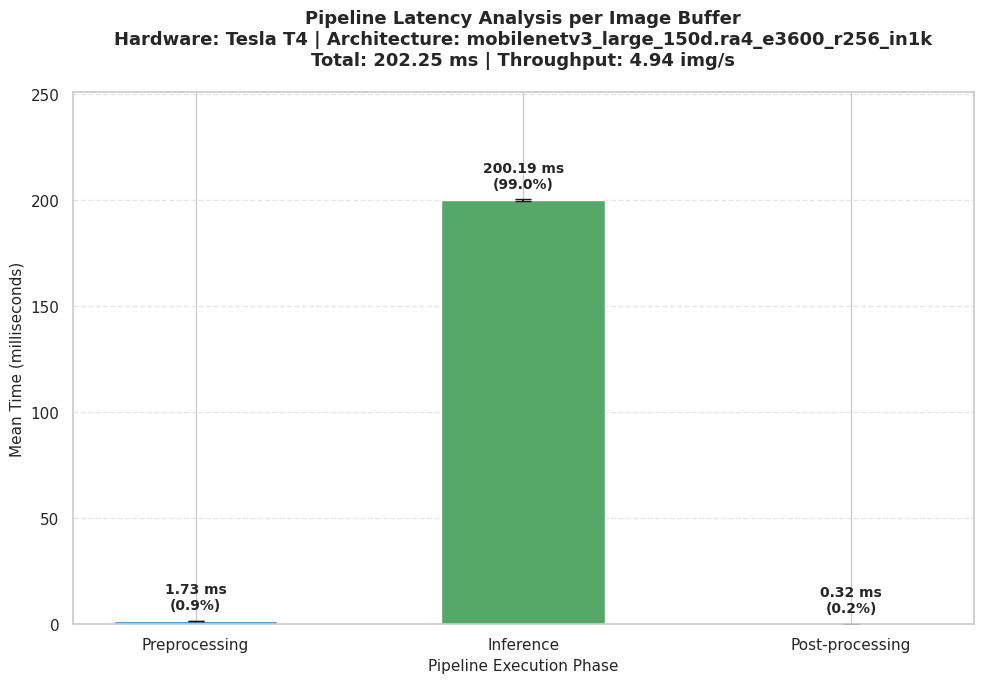


[SUCESSO] Medições integradas ao escopo de viabilidade.


In [16]:
MODEL_CHECKPOINT_PATH = PATHS["TILDA"]["model_ckpt"]
CURRENT_CLASSES = {0: "good", 1: "hole", 2: "foreign_objects", 3: "oil_spot", 4: "thread_error"}

# Configurações do teste de estresse
CONFIG_BENCHMARK = {
    "model_path": MODEL_CHECKPOINT_PATH,
    "patch_size": 64,                           # Tamanho do recorte (64x64)
    "image_height": 2048,                        # Altura do buffer de varredura linear
    "image_width": 10240,                        # Largura do buffer de varredura linear
    "tau_1": 0.90,                               # Limiar de Histerese Alto
    "tau_2": 0.56,                               # Limiar de Histerese Baixo
    "num_runs": 25,                             # Total de iterações (Warmup + Oficial)
    "warmup_runs": 5,                           # Descartadas para estabilizar o clock da GPU
    "inference_batch_size": 1024,                # Tamanho do lote processado por vez na CNN
    "use_fp16": True,                           # Habilita precisão mista automática
    "use_compile": True,                        # Ativa o torch.compile para fundir kernels
    "use_multiple_gpu": False
}

# Execução protegida por verificação de ambiente
try:
    print("⏳ Iniciando rotina de teste de hardware local...")
    
    # Executa o benchmark com os parâmetros mapeados acima
    pipeline_perf = run_pipeline_speed_benchmark(**CONFIG_BENCHMARK)
    
    print("\n[SUCESSO] Medições integradas ao escopo de viabilidade.")

except FileNotFoundError:
    print(f"\n❌ [ERRO] Não foi possível encontrar o arquivo de pesos em: '{MODEL_CHECKPOINT_PATH}'")
    print("Por favor, atualize a variável 'MODEL_CHECKPOINT_PATH' com o caminho correto do seu modelo.")
    
except NameError as e:
    print(f"\n❌ [ERRO] Dependência ausente no escopo de variáveis: {str(e)}")

In [17]:
def plot_defective_validation_images(
    val_df, 
    cache_df, 
    patch_size, 
    best_t1, 
    best_t2, 
    num_classes, 
    output_dir="output_images", 
    max_inline=15
):
    """
    Gera galeria qualitativa reconstruindo as imagens originais a partir de patches
    e desenhando caixas delimitadoras coloridas por tipo de defeito.
    """
    print("\n" + "="*70)
    print("=== FASE 6: GERANDO VISUALIZAÇÃO QUALITATIVA (RECONSTRUÇÃO REAL) ===")
    print("="*70)

    # Cria a pasta de saída de segurança
    os.makedirs(output_dir, exist_ok=True)
    print(f"[INFO] Pasta de destino garantida: '{output_dir}/'")

    # Aplica o algoritmo de correção espacial (PHT/PFF)
    cache_df = cache_df.copy()
    # Adapte o nome da função abaixo para a sua função de pós-processamento ativa (ex: fast_pht ou apply_pff_fast)
    cache_df['pred_pff'] = apply_pff_fast(cache_df, best_t1, best_t2, num_classes)

    # Identifica as imagens que possuem qualquer defeito real (multi_target > 0)
    defective_groups = cache_df[cache_df['multi_target'] > 0]['group_id'].unique()
    num_images = len(defective_groups)

    if num_images == 0:
        print("[AVISO] Nenhuma imagem com defeito encontrada no set atual.")
        return

    print(f"[INFO] Encontradas {num_images} imagens com defeito real para processamento.")

    # Mapeamento de cores fixas para as classes de defeito (RGB normalizado)
    class_colors = {
        1: (1, 0, 0),    # Classe 1: Vermelho
        2: (0, 1, 0),    # Classe 2: Verde
        3: (0, 0.5, 1),  # Classe 3: Azul
        4: (1, 1, 0),    # Classe 4: Amarelo
        5: (1, 0, 1)     # Classe 5: Magenta
    }

    # Gera cores aleatórias consistentes caso existam mais classes
    for c in range(6, num_classes):
        np.random.seed(c)
        class_colors[c] = tuple(np.random.rand(3))

    inline_count = 0

    # Processa uma imagem (grupo) por vez para proteger a memória RAM
    for idx, group_id in enumerate(defective_groups):
        
        # Filtra os caminhos dos patches desta imagem específica
        if 'group_id' in val_df.columns:
            group_filepaths = val_df[val_df['group_id'] == group_id]['filepath'].tolist()
        else:
            group_filepaths = val_df[val_df['filepath'].str.contains(str(group_id), na=False)]['filepath'].tolist()

        patches_data = []

        # 1. EXTRAÇÃO DOS ÍNDICES ESPACIAIS VIA REGEX
        for fp in group_filepaths:
            match = re.search(r'_patch(\d+)_(\d+)', fp)
            if match:
                row = int(match.group(1))
                col = int(match.group(2))
                patches_data.append({
                    "filepath": fp,
                    "x": col,  # Coluna mapeia para o eixo X
                    "y": row   # Linha mapeia para o eixo Y
                })

        if len(patches_data) == 0:
            print(f"[ERRO] Nenhum patch estruturado detectado para o grupo {group_id}")
            continue

        # Determina o tamanho do Canvas dinamicamente com base nos índices extraídos
        max_x = max(p["x"] for p in patches_data)
        max_y = max(p["y"] for p in patches_data)

        canvas_h = (max_y + 1) * patch_size
        canvas_w = (max_x + 1) * patch_size

        # Cria o canvas preto para receber a colagem
        img_reconstructed = np.zeros((canvas_h, canvas_w, 3), dtype=np.uint8)

        # 2. RECONSTRUÇÃO DA IMAGEM POR COLAGEM (STITCHING)
        for p in patches_data:
            patch_img = cv2.imread(p["filepath"])
            if patch_img is None:
                continue
            
            patch_img = cv2.cvtColor(patch_img, cv2.COLOR_BGR2RGB)
            h_p, w_p = patch_img.shape[:2]

            x_pixel = p["x"] * patch_size
            y_pixel = p["y"] * patch_size

            # Garante que o patch encaixe perfeitamente dentro dos limites alocados
            img_reconstructed[y_pixel:y_pixel+h_p, x_pixel:x_pixel+w_p] = patch_img

        # Filtra as predições e alvos da imagem atual
        img_preds = cache_df[cache_df['group_id'] == group_id]

        # 3. CRIAÇÃO DA FIGURA INDIVIDUAL (3 COLUNAS)
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))

        # Função auxiliar interna para desenhar as bboxes coloridas
        def draw_boxes(ax, img, df, target_col, title):
            ax.imshow(img)
            ax.set_title(title, fontsize=13, fontweight="bold", pad=10)
            ax.axis("off")

            # Percorre apenas as linhas onde há detecção de defeito (> 0)
            for _, row_data in df[df[target_col] > 0].iterrows():
                # Correção cirúrgica de coordenadas: x_pixel acompanha a coluna ('x') e y_pixel a linha ('y')
                x_pixel = int(row_data["x"]) * patch_size
                y_pixel = int(row_data["y"]) * patch_size

                c_id = int(row_data[target_col])
                color = class_colors.get(c_id, (1, 1, 1))

                # Desenha o quadrado vazado ao redor do patch defeituoso
                rect = patches.Rectangle(
                    (x_pixel, y_pixel),
                    patch_size,
                    patch_size,
                    linewidth=2.5,
                    edgecolor=color,
                    facecolor="none"
                )
                ax.add_patch(rect)

        # Renderiza as 3 colunas comparativas
        draw_boxes(axes[0], img_reconstructed, img_preds, "multi_target", f"Ground Truth (Real)\nID: {group_id}")
        draw_boxes(axes[1], img_reconstructed, img_preds, "pred_raw", "Baseline (CNN Crua)")
        draw_boxes(axes[2], img_reconstructed, img_preds, "pred_pff", f"PHT Corrigido\n(t1={best_t1}, t2={best_t2})")

        # Configura a legenda dinâmica baseada nas classes encontradas
        legend_patches = [
            patches.Patch(color=class_colors[c], label=f"Defeito Classe {c}")
            for c in range(1, num_classes)
        ]
        fig.legend(
            handles=legend_patches,
            loc="upper center",
            ncol=num_classes - 1,
            fontsize=11,
            bbox_to_anchor=(0.5, 0.98)
        )

        plt.tight_layout()
        fig.subplots_adjust(top=0.85)

        # 4. SALVAMENTO AUTOMÁTICO EM DISCO (Segurança de todas as imagens)
        save_path = os.path.join(output_dir, f"reconstrucao_{group_id}.png")
        plt.savefig(save_path, bbox_inches='tight', dpi=120)

        # 5. CONTROLE DE MEMÓRIA INLINE (Exibe apenas até o limite definido)
        if inline_count < max_inline:
            plt.show()
            inline_count += 1
        else:
            plt.close(fig)  # Libera a memória RAM imediatamente sem plotar na tela

    print(f"\n✅ Catálogo gerado com sucesso! {num_images} inspeções salvas em '{output_dir}/'.")
    print(f"👁️ Exibindo as primeiras {inline_count} imagens inline para análise de qualidade.")

In [18]:
def plot_defective_images_tilda(
    df, 
    patch_size=64, 
    num_classes=4, 
    base_image_dir="/kaggle/input/datasets/angelolmg/tilda-400/images",
    output_dir="output_images", 
    max_inline=15
):
    """
    Gera a galeria qualitativa abrindo as imagens originais do TILDA
    e desenhando caixas coloridas por tipo de defeito mapeado no df_tilda.
    """
    print("\n" + "="*70)
    print("=== FASE 6: GERANDO VISUALIZAÇÃO QUALITATIVA (TILDA) ===")
    print("="*70)

    # Cria a pasta de saída para salvar os relatórios visuais
    os.makedirs(output_dir, exist_ok=True)
    print(f"[INFO] Pasta de segurança garantida: '{output_dir}/'")

    # Mapeamento exato das colunas do seu DataFrame
    target_col = "y_multi"
    raw_col = "pred_raw_multi"
    pht_col = "pred_pht_multi"
    img_id_col = "img_id"

    # Filtra os IDs das imagens que contêm qualquer defeito real (classe > 0)
    defective_images = df[df[target_col] > 0][img_id_col].unique()
    num_images = len(defective_images)

    if num_images == 0:
        print("[AVISO] Nenhuma imagem com defeito real (>0) encontrada no df_tilda.")
        return

    print(f"[INFO] Encontradas {num_images} imagens com defeito real para plotagem.")

    # Mapeamento de cores fixas (RGB normalizado) para os quadrados dos defeitos
    class_colors = {
        1: (1, 0, 0),    # Classe 1: Vermelho
        2: (0, 1, 0),    # Classe 2: Verde
        3: (0, 0.5, 1),  # Classe 3: Azul
        4: (1, 1, 0),    # Classe 4: Amarelo
        5: (1, 0, 1)     # Classe 5: Magenta
    }

    inline_count = 0

    # Itera sobre cada imagem com defeito
    for img_id in defective_images:
        
        # Monta o caminho correto da imagem original baseado no seu input do Kaggle
        img_filename = f"{img_id}.tif"
        full_img_path = os.path.join(base_image_dir, img_filename)
        
        # Carrega a imagem têxtil original completa
        img_original = cv2.imread(full_img_path)
        if img_original is None:
            print(f"[AVISO] Não foi possível carregar a imagem original em: {full_img_path}. Pulando...")
            continue
            
        img_original = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)
        
        # Isola as linhas do dataframe que pertencem a esta imagem específica
        df_img = df[df[img_id_col] == img_id]

        # Inicializa a plotagem comparativa de 3 colunas
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))

        # Função interna para desenhar as caixas delimitadoras coloridas por patch
        def draw_boxes(ax, base_img, dataframe, col_name, title):
            # Mostra a imagem original de fundo
            ax.imshow(base_img)
            ax.set_title(title, fontsize=13, fontweight="bold", pad=10)
            ax.axis("off")

            # Percorre apenas as linhas onde há defeito detectado nesta coluna (> 0)
            for _, row_data in dataframe[dataframe[col_name] > 0].iterrows():
                # Coordenadas diretas fornecidas pelo seu df_tilda
                p_row = int(row_data["row"])
                p_col = int(row_data["col"])
                
                # Mapeia os índices do grid para pixels na imagem real
                x_pixel = p_col * patch_size
                y_pixel = p_row * patch_size
                
                classe_defeito = int(row_data[col_name])
                color = class_colors.get(classe_defeito, (1, 1, 1))

                # Cria o retângulo vazado
                rect = patches.Rectangle(
                    (x_pixel, y_pixel),
                    patch_size,
                    patch_size,
                    linewidth=2.5,
                    edgecolor=color,
                    facecolor="none"
                )
                ax.add_patch(rect)

        # Renderiza os três cenários lado a lado
        draw_boxes(axes[0], img_original, df_img, target_col, f"Ground Truth (Real)\nID: {img_id}")
        draw_boxes(axes[1], img_original, df_img, raw_col, "Baseline (CNN Crua)")
        draw_boxes(axes[2], img_original, df_img, pht_col, "PHT Corrigido (Proposto)")

        # Cria a legenda dinâmica baseada no número de classes fornecido
        legend_patches = [
            patches.Patch(color=class_colors[c], label=f"Defeito Classe {c}")
            for c in range(1, num_classes + 1)
        ]
        fig.legend(
            handles=legend_patches,
            loc="upper center",
            ncol=len(legend_patches),
            fontsize=11,
            bbox_to_anchor=(0.5, 0.98)
        )

        plt.tight_layout()
        fig.subplots_adjust(top=0.85)

        # Salva a imagem em disco (Garante o relatório completo)
        save_path = os.path.join(output_dir, f"inspecao_{img_id}.png")
        plt.savefig(save_path, bbox_inches='tight', dpi=120)

        # Controle rígido de RAM inline no ambiente do Kaggle
        if inline_count < max_inline:
            plt.show()
            inline_count += 1
        else:
            plt.close(fig)

    print(f"\n✅ Concluído! Todas as {num_images} imagens de inspeção foram salvas em '{output_dir}/'.")
    print(f"🖼️ Exibindo as primeiras {inline_count} imagens inline para validação visual rápida.")


=== FASE 6: GERANDO VISUALIZAÇÃO QUALITATIVA (TILDA) ===
[INFO] Pasta de segurança garantida: 'output_images_fase6/'
[INFO] Encontradas 80 imagens com defeito real para plotagem.


[ WARN:0@125.820] global grfmt_tiff.cpp:122 TIFF_Warning TIFFFetchNormalTag: ASCII value for tag "ImageDescription" does not end in null byte. Forcing it to be null


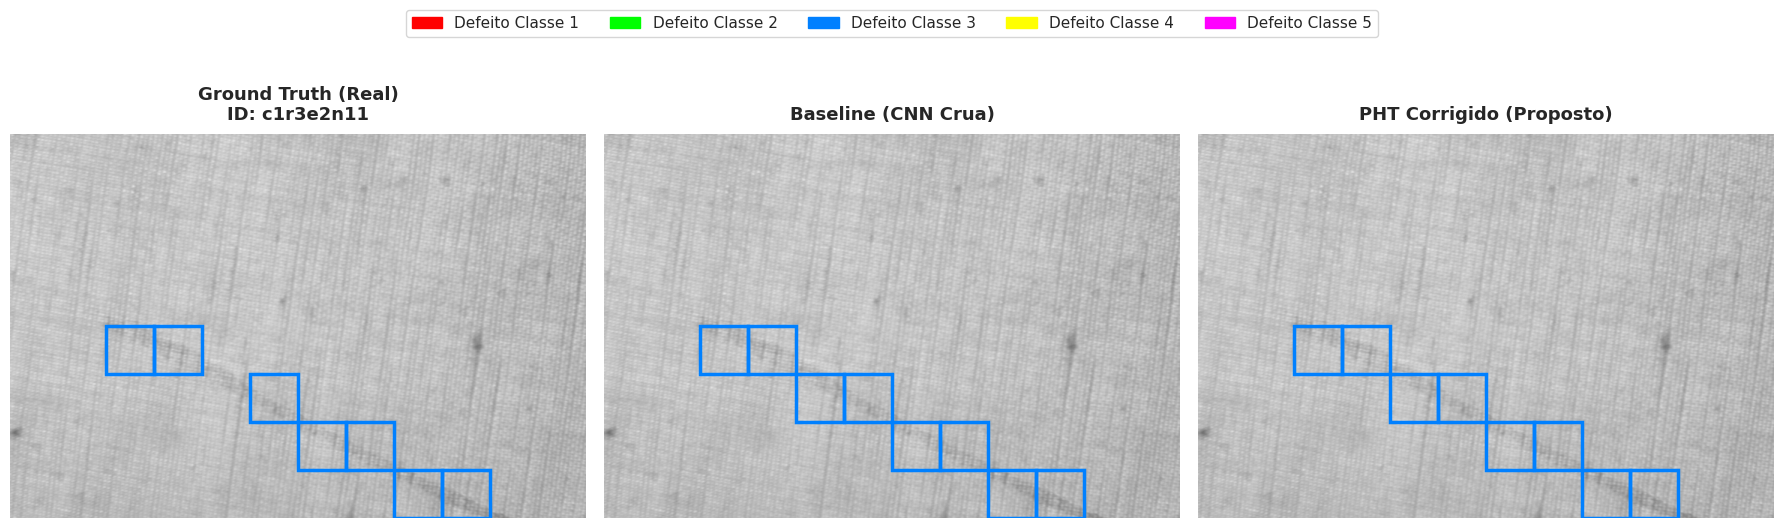

[ WARN:0@126.727] global grfmt_tiff.cpp:122 TIFF_Warning TIFFFetchNormalTag: ASCII value for tag "ImageDescription" does not end in null byte. Forcing it to be null


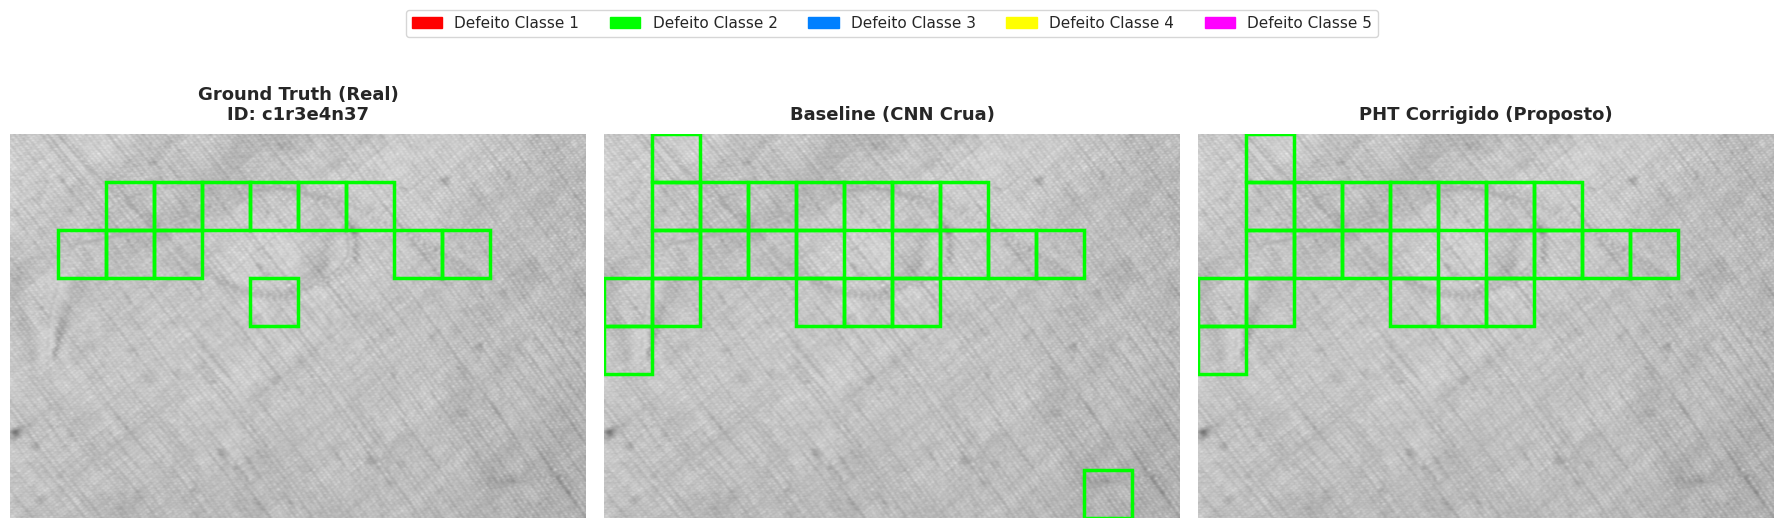

[ WARN:0@127.681] global grfmt_tiff.cpp:122 TIFF_Warning TIFFFetchNormalTag: ASCII value for tag "ImageDescription" does not end in null byte. Forcing it to be null


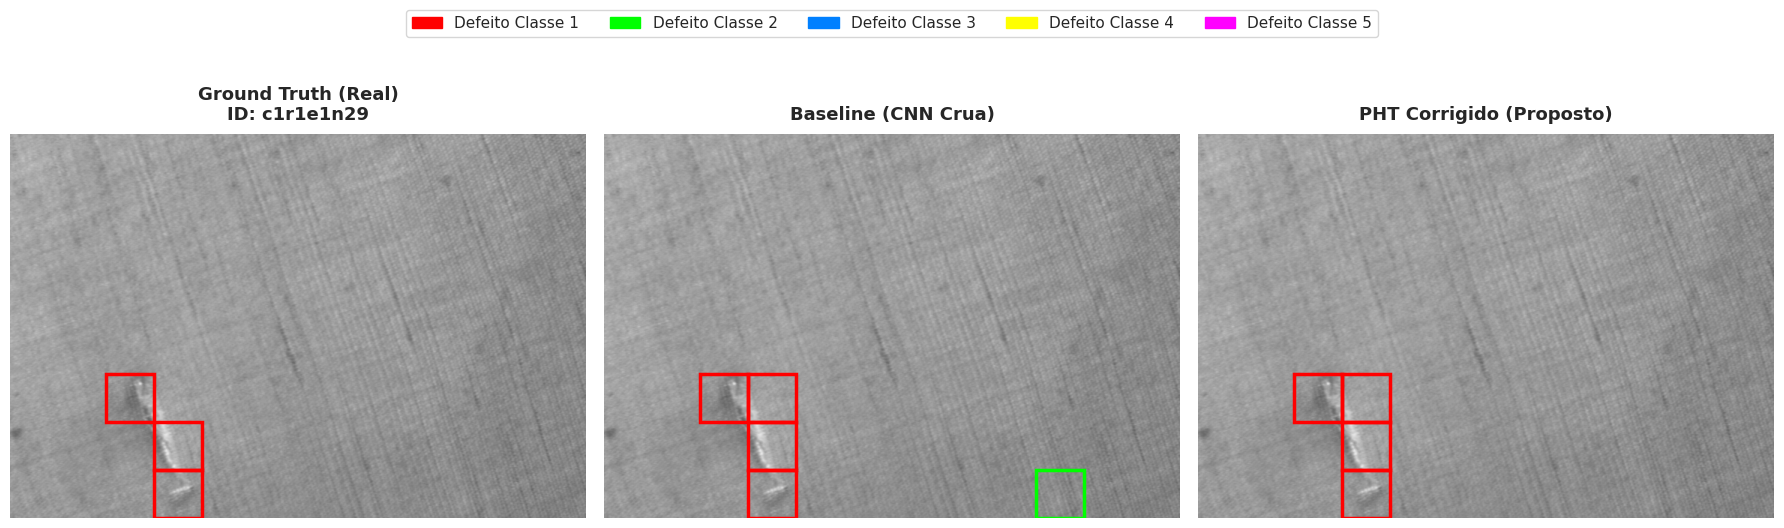

[ WARN:0@128.549] global grfmt_tiff.cpp:122 TIFF_Warning TIFFFetchNormalTag: ASCII value for tag "ImageDescription" does not end in null byte. Forcing it to be null


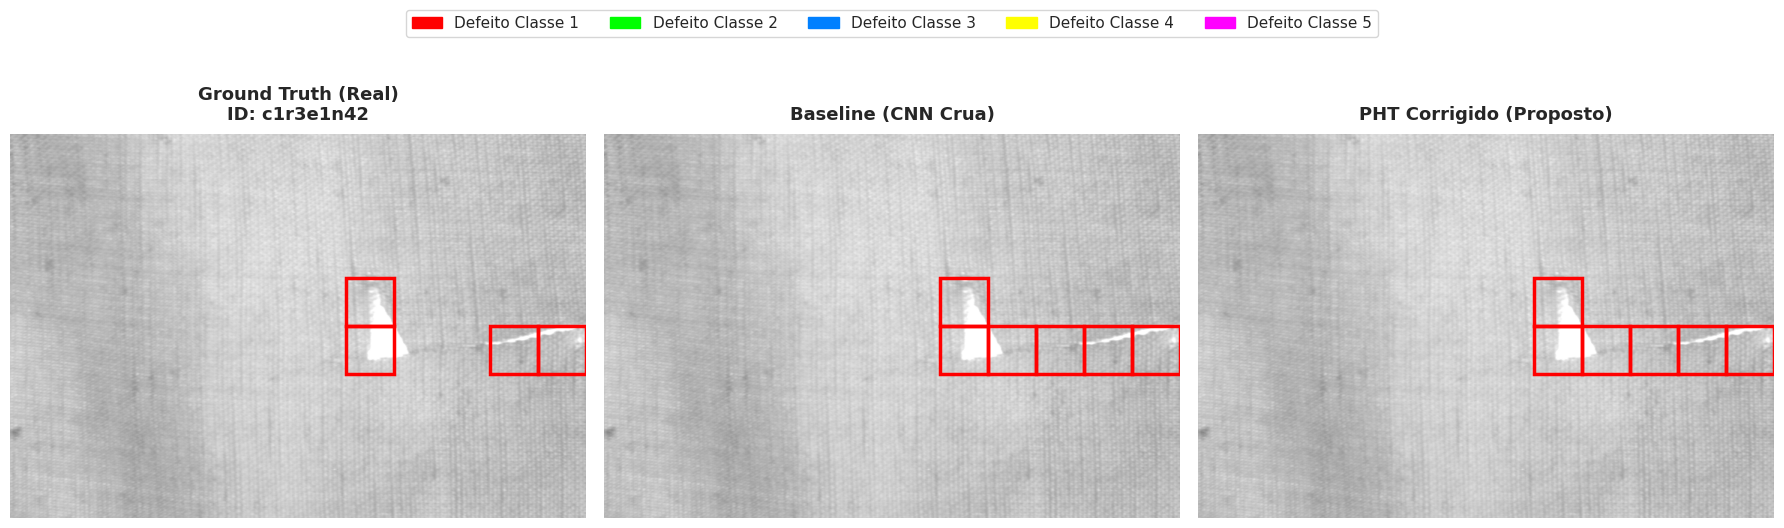

[ WARN:0@129.506] global grfmt_tiff.cpp:122 TIFF_Warning TIFFFetchNormalTag: ASCII value for tag "ImageDescription" does not end in null byte. Forcing it to be null


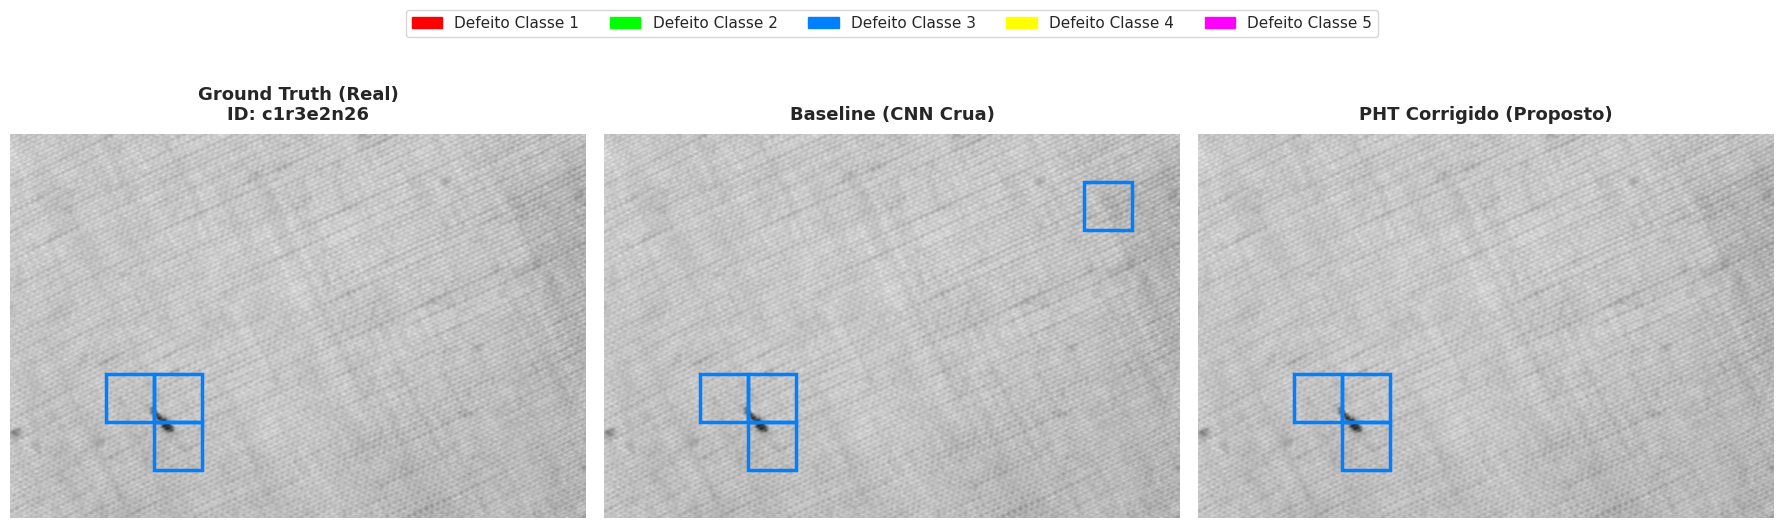

[ WARN:0@130.428] global grfmt_tiff.cpp:122 TIFF_Warning TIFFFetchNormalTag: ASCII value for tag "ImageDescription" does not end in null byte. Forcing it to be null


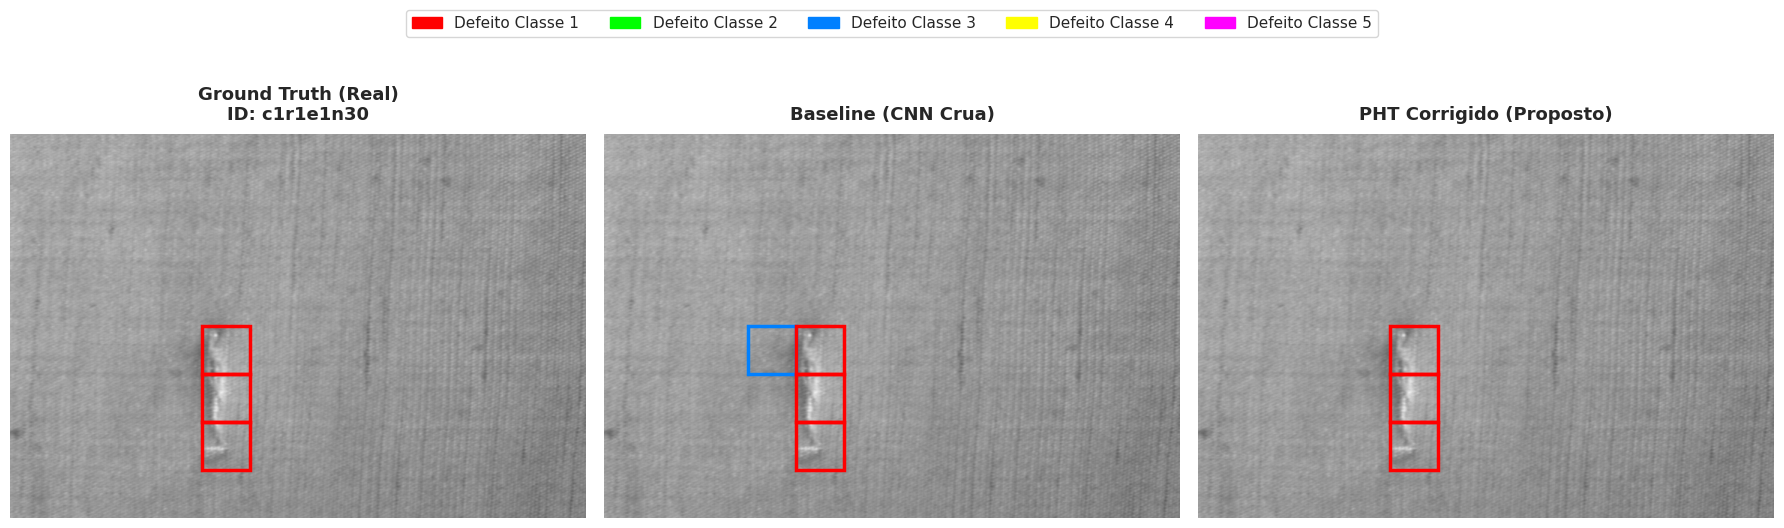

[ WARN:0@131.314] global grfmt_tiff.cpp:122 TIFF_Warning TIFFFetchNormalTag: ASCII value for tag "ImageDescription" does not end in null byte. Forcing it to be null


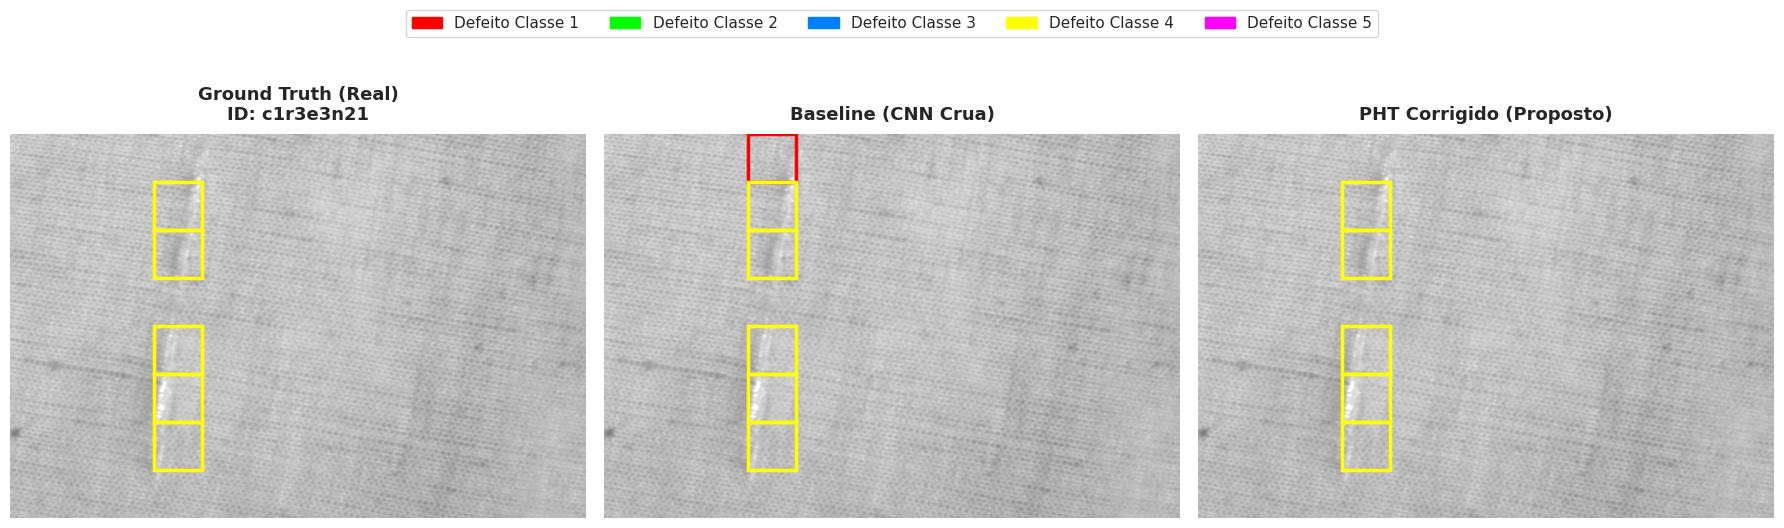

[ WARN:0@132.162] global grfmt_tiff.cpp:122 TIFF_Warning TIFFFetchNormalTag: ASCII value for tag "ImageDescription" does not end in null byte. Forcing it to be null


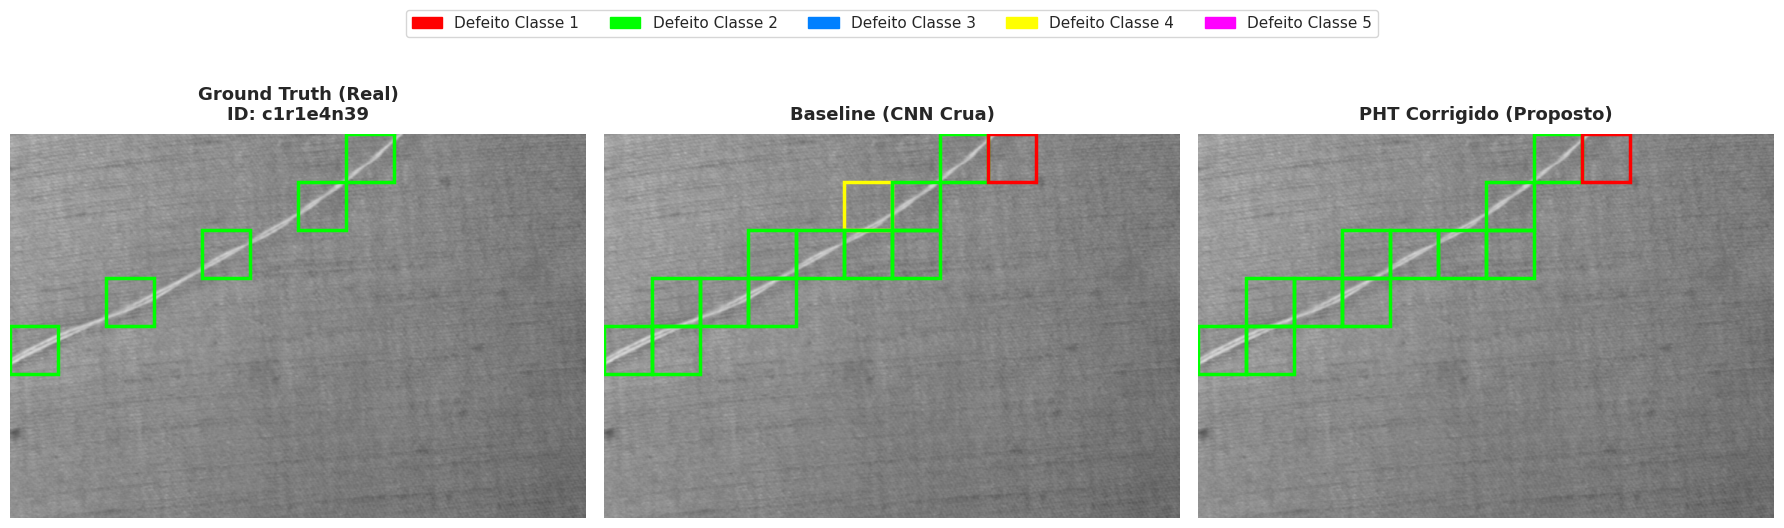

[ WARN:0@133.080] global grfmt_tiff.cpp:122 TIFF_Warning TIFFFetchNormalTag: ASCII value for tag "ImageDescription" does not end in null byte. Forcing it to be null
[ WARN:0@133.670] global grfmt_tiff.cpp:122 TIFF_Warning TIFFFetchNormalTag: ASCII value for tag "ImageDescription" does not end in null byte. Forcing it to be null
[ WARN:0@134.218] global grfmt_tiff.cpp:122 TIFF_Warning TIFFFetchNormalTag: ASCII value for tag "ImageDescription" does not end in null byte. Forcing it to be null
[ WARN:0@134.787] global grfmt_tiff.cpp:122 TIFF_Warning TIFFFetchNormalTag: ASCII value for tag "ImageDescription" does not end in null byte. Forcing it to be null
[ WARN:0@135.904] global grfmt_tiff.cpp:122 TIFF_Warning TIFFFetchNormalTag: ASCII value for tag "ImageDescription" does not end in null byte. Forcing it to be null
[ WARN:0@136.469] global grfmt_tiff.cpp:122 TIFF_Warning TIFFFetchNormalTag: ASCII value for tag "ImageDescription" does not end in null byte. Forcing it to be null
[ WARN:0@1


✅ Concluído! Todas as 80 imagens de inspeção foram salvas em 'output_images_fase6/'.
🖼️ Exibindo as primeiras 8 imagens inline para validação visual rápida.


In [19]:
# Execução direta e limpa
plot_defective_images_tilda(
    df=df_tilda,          # Seu DataFrame unificado
    patch_size=64,        # Resolução padrão dos patches
    num_classes=5,        # Altere para a quantidade de classes de defeito do seu modelo
    output_dir="output_images_fase6",
    max_inline=8         # Limite seguro para renderização em tela
)

In [20]:
def plot_defective_images_agnostic(
    df, 
    base_image_dir,
    patch_size=64, 
    num_classes=4,
    image_ext=".png",
    col_mapping=None,
    output_dir="output_images", 
    max_inline=15
):
    """
    Gera galeria qualitativa agnóstica a dataset, desenhando as caixas de defeitos
    diretamente sobre as imagens originais de alta resolução.
    """
    # Silencia avisos do OpenCV (ex: TIFF_Warning)
    os.environ["OPENCV_LOG_LEVEL"] = "ERROR"

    print("\n" + "="*70)
    print(f"=== FASE 6: GERANDO VISUALIZAÇÃO QUALITATIVA (AGNÓSTICA) ===")
    print("="*70)

    os.makedirs(output_dir, exist_ok=True)

    # Dicionário padrão de mapeamento de colunas (caso não seja fornecido)
    if col_mapping is None:
        col_mapping = {
            "id": "img_id",
            "target": "y_multi",
            "raw": "pred_raw_multi",
            "pht": "pred_pht_multi",
            "row": "row",
            "col": "col"
        }

    # Extrai os nomes das colunas do mapeamento
    id_col = col_mapping["id"]
    target_col = col_mapping["target"]
    raw_col = col_mapping["raw"]
    pht_col = col_mapping["pht"]
    row_col = col_mapping["row"]
    col_col = col_mapping["col"]

    # Validação rápida de segurança
    for col in [id_col, target_col, raw_col, pht_col, row_col, col_col]:
        if col not in df.columns:
            print(f"[ERRO] A coluna obrigatória '{col}' não foi encontrada no DataFrame.")
            return

    # Filtra imagens com defeito real
    defective_images = df[df[target_col] > 0][id_col].unique()
    num_images = len(defective_images)

    if num_images == 0:
        print("[AVISO] Nenhuma imagem com defeito real encontrada no DataFrame fornecido.")
        return

    print(f"[INFO] Encontradas {num_images} imagens com defeito real. Lendo de: {base_image_dir}")

    # Paleta de cores para os defeitos
    class_colors = {
        1: (1, 0, 0), 2: (0, 1, 0), 3: (0, 0.5, 1), 4: (1, 1, 0), 5: (1, 0, 1)
    }
    for c in range(6, num_classes + 1):
        np.random.seed(c)
        class_colors[c] = tuple(np.random.rand(3))

    inline_count = 0

    for img_id in defective_images:
        
        # Resolve a extensão da imagem de forma flexível
        img_id_str = str(img_id)
        if img_id_str.endswith(image_ext):
            img_filename = img_id_str
        else:
            img_filename = f"{img_id_str}{image_ext}"
            
        full_img_path = os.path.join(base_image_dir, img_filename)
        
        img_original = cv2.imread(full_img_path)
        if img_original is None:
            print(f"[AVISO] Imagem original não encontrada: {full_img_path}. Pulando...")
            continue
            
        img_original = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)
        df_img = df[df[id_col] == img_id]

        fig, axes = plt.subplots(1, 3, figsize=(18, 6))

        def draw_boxes(ax, base_img, dataframe, target_metric_col, title):
            ax.imshow(base_img)
            ax.set_title(title, fontsize=13, fontweight="bold", pad=10)
            ax.axis("off")

            for _, row_data in dataframe[dataframe[target_metric_col] > 0].iterrows():
                x_pixel = int(row_data[col_col]) * patch_size
                y_pixel = int(row_data[row_col]) * patch_size
                classe_defeito = int(row_data[target_metric_col])
                
                rect = patches.Rectangle(
                    (x_pixel, y_pixel), patch_size, patch_size,
                    linewidth=2.5, edgecolor=class_colors.get(classe_defeito, (1, 1, 1)), facecolor="none"
                )
                ax.add_patch(rect)

        draw_boxes(axes[0], img_original, df_img, target_col, f"Ground Truth (Real)\nID: {img_id}")
        draw_boxes(axes[1], img_original, df_img, raw_col, "Baseline (CNN Crua)")
        draw_boxes(axes[2], img_original, df_img, pht_col, "PHT Corrigido (Proposto)")

        legend_patches = [patches.Patch(color=class_colors[c], label=f"Classe {c}") for c in range(1, num_classes + 1)]
        fig.legend(handles=legend_patches, loc="upper center", ncol=len(legend_patches), fontsize=11, bbox_to_anchor=(0.5, 0.98))

        plt.tight_layout()
        fig.subplots_adjust(top=0.85)

        save_path = os.path.join(output_dir, f"inspecao_{img_id}.png")
        plt.savefig(save_path, bbox_inches='tight', dpi=120)

        if inline_count < max_inline:
            plt.show()
            inline_count += 1
        else:
            plt.close(fig)

    print(f"\n✅ {num_images} imagens foram processadas e salvas em '{output_dir}/'.")

In [21]:
# tilda_col_mapping = {
#     "id": "img_id", 
#     "target": "y_multi", 
#     "raw": "pred_raw_multi", 
#     "pht": "pred_pht_multi", 
#     "row": "row", 
#     "col": "col"
# }

# plot_defective_images_agnostic(
#     df=df_tilda,
#     base_image_dir="/kaggle/input/datasets/angelolmg/tilda-400/images",
#     patch_size=64,
#     num_classes=4,
#     image_ext=".tif",
#     col_mapping=tilda_col_mapping,
#     output_dir="output_tilda",
#     max_inline=80
# )

In [22]:
# def plot_defective_images_agnostic(
#     df, 
#     base_image_dir,
#     patch_size=64, 
#     num_classes=4,
#     image_ext=".png",
#     col_mapping=None,
#     output_dir="output_images", 
#     max_inline=15
# ):
#     """
#     Gera galeria qualitativa agnóstica. Suporta busca recursiva em subpastas
#     e resolve automaticamente prefixos em IDs de imagem (ex: box_Bbox_tk_d6 -> Bbox_tk_d6.bmp).
#     """
#     os.environ["OPENCV_LOG_LEVEL"] = "ERROR"

#     print("\n" + "="*70)
#     print("=== FASE 6: GERANDO VISUALIZAÇÃO QUALITATIVA (RECONSTRUÇÃO REAL) ===")
#     print("="*70)

#     os.makedirs(output_dir, exist_ok=True)

#     # 1. MAPEAMENTO DE COLUNAS PADRÃO (Mesmo para TILDA e HKU)
#     if col_mapping is None:
#         col_mapping = {
#             "id": "img_id",
#             "target": "y_multi",
#             "raw": "pred_raw_multi",
#             "pht": "pred_pht_multi",
#             "row": "row",
#             "col": "col"
#         }

#     id_col = col_mapping["id"]
#     target_col = col_mapping["target"]
#     raw_col = col_mapping["raw"]
#     pht_col = col_mapping["pht"]
#     row_col = col_mapping["row"]
#     col_col = col_mapping["col"]

#     # 2. CONSTRUÇÃO DO MAPA DE CAMINHOS RECURSIVO (Protege a velocidade do Kaggle)
#     print(f"[🔍 INDEXAÇÃO] Mapeando arquivos '{image_ext}' em todas as subpastas de '{base_image_dir}'...")
#     image_path_map = {}
    
#     for root, _, files in os.walk(base_image_dir):
#         for file in files:
#             if file.lower().endswith(image_ext.lower()):
#                 # Armazena o nome completo do arquivo como chave e o caminho absoluto como valor
#                 image_path_map[file] = os.path.join(root, file)
                
#     print(f"📁 Indexação concluída! {len(image_path_map)} imagens mapeadas em memória.")

#     # Filtra imagens com defeito real
#     defective_images = df[df[target_col] > 0][id_col].unique()
#     num_images = len(defective_images)

#     if num_images == 0:
#         print("[AVISO] Nenhuma imagem com defeito real encontrada no DataFrame.")
#         return

#     print(f"[INFO] Processando {num_images} imagens com defeito real.")

#     # Cores dos Bounding Boxes
#     class_colors = {
#         1: (1, 0, 0), 2: (0, 1, 0), 3: (0, 0.5, 1), 4: (1, 1, 0), 5: (1, 0, 1)
#     }
#     for c in range(6, num_classes + 1):
#         np.random.seed(c)
#         class_colors[c] = tuple(np.random.rand(3))

#     inline_count = 0

#     # 3. LOOP PRINCIPAL DE RESOLUÇÃO E PLOTAGEM
#     for img_id in defective_images:
#         img_id_str = str(img_id)
        
#         # --- ESTRATÉGIA DE BUSCA EM DOIS PASSOS ---
#         # Passo A: Tenta o nome exato vindo do dataframe
#         target_filename = img_id_str if img_id_str.endswith(image_ext) else f"{img_id_str}{image_ext}"
        
#         # Passo B (Caso HKU): Se não achar, remove o primeiro prefixo antes do '_'
#         if target_filename not in image_path_map and "_" in img_id_str:
#             # Separa no primeiro '_' e pega o resto (ex: 'box_Bbox_tk_d6' -> 'Bbox_tk_d6')
#             cleaned_id = img_id_str.split("_", 1)[1]
#             target_filename = cleaned_id if cleaned_id.endswith(image_ext) else f"{cleaned_id}{image_ext}"

#         # Verifica se o arquivo foi localizado pelo mapeamento prévio
#         if target_filename in image_path_map:
#             full_img_path = image_path_map[target_filename]
#         else:
#             print(f"[AVISO] Arquivo '{target_filename}' (ID original: '{img_id_str}') não localizado nas subpastas. Pulando...")
#             continue
            
#         # Carrega a imagem localizada
#         img_original = cv2.imread(full_img_path)
#         if img_original is None:
#             continue
            
#         img_original = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)
#         df_img = df[df[id_col] == img_id]

#         fig, axes = plt.subplots(1, 3, figsize=(18, 6))

#         def draw_boxes(ax, base_img, dataframe, target_metric_col, title):
#             ax.imshow(base_img)
#             ax.set_title(title, fontsize=13, fontweight="bold", pad=10)
#             ax.axis("off")

#             for _, row_data in dataframe[dataframe[target_metric_col] > 0].iterrows():
#                 x_pixel = int(row_data[col_col]) * patch_size
#                 y_pixel = int(row_data[row_col]) * patch_size
#                 classe_defeito = int(row_data[target_metric_col])
                
#                 rect = patches.Rectangle(
#                     (x_pixel, y_pixel), patch_size, patch_size,
#                     linewidth=2.5, edgecolor=class_colors.get(classe_defeito, (1, 1, 1)), facecolor="none"
#                 )
#                 ax.add_patch(rect)

#         # Renderização das colunas
#         draw_boxes(axes[0], img_original, df_img, target_col, f"Ground Truth (Real)\nID: {target_filename}")
#         draw_boxes(axes[1], img_original, df_img, raw_col, "Baseline (CNN Crua)")
#         draw_boxes(axes[2], img_original, df_img, pht_col, "PHT Corrigido (Proposto)")

#         legend_patches = [patches.Patch(color=class_colors[c], label=f"Classe {c}") for c in range(1, num_classes + 1)]
#         fig.legend(handles=legend_patches, loc="upper center", ncol=len(legend_patches), fontsize=11, bbox_to_anchor=(0.5, 0.98))

#         plt.tight_layout()
#         fig.subplots_adjust(top=0.85)

#         save_path = os.path.join(output_dir, f"inspecao_{target_filename.split('.')[0]}.png")
#         plt.savefig(save_path, bbox_inches='tight', dpi=120)

#         if inline_count < max_inline:
#             plt.show()
#             inline_count += 1
#         else:
#             plt.close(fig)

#     print(f"\n✅ Concluído! Imagens salvas com sucesso no diretório '{output_dir}/'.")

In [23]:
# plot_defective_images_agnostic(
#     df=df_hku, # Substitua pelo nome da sua variável do DataFrame do HKU
#     base_image_dir="/kaggle/input/datasets/angelogoes/hku-dataset",
#     patch_size=64,
#     num_classes=7,
#     image_ext=".bmp",
#     output_dir="output_images_hku",
#     max_inline=2
# )

In [24]:
# plot_defective_images_agnostic(
#     df=df_tilda,
#     base_image_dir="/kaggle/input/datasets/angelolmg/tilda-400/images",
#     patch_size=64,
#     num_classes=5,
#     image_ext=".tif",
#     output_dir="output_images_tilda",
#     max_inline=33
# )